# Test Evaluation

The aim of this notebook is to create portfolios for each combination of model and metric on test data and then explore the results.

## Setup

In [1]:
import itertools
import json
import math
import os
from pathlib import Path
from typing import get_args

import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed

In [2]:
# Find project root (folder that contains .git)
ROOT = Path.cwd()
while not (ROOT / ".git").exists():
    ROOT = ROOT.parent

# Set working directory to root
os.chdir(ROOT)

print("Now working in:", Path.cwd())

Now working in: C:\Users\couch\OneDrive\Assignments\Master Thesis\Repo


In [3]:
from src.config import TEST_END, TEST_MODELS, TEST_START
from src.metrics import MetricName, compute_metric, expected_shortfall

In [4]:
sns.set_theme(style="whitegrid")

In [5]:
METRIC_MAPPING = {
    "tail_effectiveness": "R(1)",
    "omega": "R(2)",
    "sortino": "R(3)",
    "central_tail_effectiveness": "D(1)",
    "central_sortino": "D(2)",
    "sharpe": "D(3)",
}
METRIC_MAPPING_SUMMARY = {
    "R(1)": "tail_effectiveness",
    "R(2)": "omega",
    "R(3)": "sortino",
    "D(1)": "central_tail_effectiveness",
    "D(2)": "central_sortino",
    "D(3)": "sharpe",
}
SEGMENT_MAPPING = {
    "ALR": "Finanse",
    "CDR": "Media",
    "CPS": "Media",
    "DNP": "Handel detaliczny",
    "EBP": "Finanse",
    "JSW": "Energetyka",
    "KGH": "Energetyka",
    "LPP": "Handel detaliczny",
    "LTS": "Energetyka",
    "MBK": "Finanse",
    "MDV": "Handel detaliczny",
    "OPL": "Media",
    "PEO": "Finanse",
    "PGE": "Energetyka",
    "PGN": "Energetyka",
    "PKN": "Energetyka",
    "PKO": "Finanse",
    "PLY": "Media",
    "PZU": "Finanse",
    "TPE": "Energetyka",
}

## Evaluation

This section performs calculations and loads the final result into one large DataFrame.

In [6]:
def run_single_combination(params):
    import os
    import sys
    from pathlib import Path

    # Find project root (folder that contains .git)
    ROOT = Path.cwd()
    while not (ROOT / ".git").exists():
        ROOT = ROOT.parent

    # Set working directory AND update Python's import path
    os.chdir(ROOT)
    if str(ROOT) not in sys.path:
        sys.path.insert(0, str(ROOT))

    # Suppress all tqdm progress bars in this process
    os.environ["TQDM_DISABLE"] = "1"

    from src.config import TEST_END, TEST_START, WINDOW_SIZE
    from src.simulation import run_backtest

    metric, model_tuple = params
    mean_model, volatility_model, _ = model_tuple

    results_dir = Path("results/test_evaluation")

    combo_dir = results_dir / metric
    data_dir = combo_dir / "data"
    logs_dir = combo_dir / "logs"

    data_dir.mkdir(parents=True, exist_ok=True)
    logs_dir.mkdir(parents=True, exist_ok=True)

    result_file = data_dir / f"{mean_model}_{volatility_model}.parquet"
    log_file = logs_dir / f"{mean_model}_{volatility_model}.txt"

    if result_file.exists():
        return

    df = pd.read_parquet("results/processed_data/stock_data.parquet", engine="pyarrow")
    df.index = pd.to_datetime(df.index)
    df = df[df.index <= TEST_END]

    run_backtest(
        df,
        window_size=WINDOW_SIZE,
        start_date=TEST_START,
        end_date=TEST_END,
        mean_model=mean_model,
        volatility_model=volatility_model,
        optimize_portfolio_flag=True,
        save_path=result_file,
        ga_metric=metric,
        rf_rates_path="results/processed_data/risk_free_rate.json",
        log_path=log_file,
    )

    print(f"Finished ({mean_model}, {volatility_model}) for {metric}", flush=True)


param_combinations = list(itertools.product(list(get_args(MetricName)), TEST_MODELS))

Parallel(n_jobs=4, backend="loky", batch_size=1)(delayed(run_single_combination)(p) for p in param_combinations)
print("Finished backtest for all combinations")

Finished backtest for all combinations


In [7]:
results_dir = Path("results/test_evaluation")

In [8]:
# Define weight columns corresponding to segments
segments = sorted(list(set(SEGMENT_MAPPING.values())))
segment_weight_columns = {
    segment: [f"weight_{ticker}" for ticker, s in SEGMENT_MAPPING.items() if s == segment] for segment in segments
}

# Load risk-free rate of return
with open("results/processed_data/risk_free_rate.json") as f:
    rf_dict = json.load(f)

# Load index returns
index_df = pd.read_parquet("results/processed_data/index_returns.parquet")
index_df.index = pd.to_datetime(index_df.index)
index_series = index_df.loc[(index_df.index >= TEST_START) & (index_df.index <= TEST_END), "Return"]

# Load data from each model and metric
all_records = []

for metric_dir in sorted([d for d in results_dir.iterdir() if d.is_dir()]):
    target_metric_name = metric_dir.name
    data_dir = metric_dir / "data"
    if not data_dir.exists():
        continue

    for parquet_file in sorted(data_dir.glob("*.parquet")):
        model_combo_name = parquet_file.stem
        metric_df = pd.read_parquet(parquet_file, engine="pyarrow")
        metric_df.index = pd.to_datetime(metric_df.index)

        if model_combo_name.startswith("naive"):
            model_name = "Brak modelu"
        else:
            model_name = model_combo_name.split("_")[-1].upper()
            if model_name == "GARCH":
                model_name = "GO-GARCH"

        # Load the risk-free rate of return
        rf_series = metric_df.index.strftime("%Y-%m").map(rf_dict).astype(float)

        # Calculate allocation for each segment
        segment_allocations = {}
        for segment, weight_cols in segment_weight_columns.items():
            existing_cols = [c for c in weight_cols if c in metric_df.columns]
            if existing_cols:
                segment_allocations[segment] = metric_df[existing_cols].sum(axis=1)
            else:
                segment_allocations[segment] = 0.0

        # Define the records
        model_df = pd.DataFrame(
            {
                "date": metric_df.index,
                "target_metric": METRIC_MAPPING[target_metric_name],
                "model": model_name,
                "return": metric_df["portfolio_return"],
                "excess_return": metric_df["portfolio_return"] - rf_series,
                "turnover": metric_df["turnover"],
                **segment_allocations,
            }
        )

        all_records.append(model_df)

# Join all models and metrics
combined_long_df = pd.concat(all_records, ignore_index=True)

# Add rows for risk-free and index
benchmark_dfs = []
unique_target_metrics = combined_long_df["target_metric"].unique()

for tm in unique_target_metrics:
    # Defensive programming for changing dates
    tm_dates = combined_long_df[combined_long_df["target_metric"] == tm]["date"].drop_duplicates().sort_values()

    rf_vals = tm_dates.dt.strftime("%Y-%m").map(rf_dict).astype(float).values
    idx_vals = index_series.reindex(tm_dates).values

    # Get NaNs for segment columns
    segment_nans = {segment: np.nan for segment in segments}

    # Risk_free
    rf_df = pd.DataFrame(
        {
            "date": tm_dates,
            "target_metric": tm,
            "model": "Stopa wolna od ryzyka",
            "return": rf_vals,
            "excess_return": 0.0,
            "turnover": np.nan,
            **segment_nans,
        }
    )

    # Index
    idx_df = pd.DataFrame(
        {
            "date": tm_dates,
            "target_metric": tm,
            "model": "WIG20",
            "return": idx_vals,
            "excess_return": idx_vals - rf_vals,
            "turnover": np.nan,
            **segment_nans,
        }
    )

    benchmark_dfs.extend([rf_df, idx_df])

# Combine everything and add extra columns
final_df = (
    pd.concat([combined_long_df] + benchmark_dfs, ignore_index=True)
    .sort_values(by=["target_metric", "model", "date"])
    .reset_index(drop=True)
)
final_df["year"] = final_df["date"].dt.year
final_df["cum_return"] = final_df.groupby(["target_metric", "model"])["return"].transform(
    lambda r: (1 + r).cumprod() - 1
)

final_df

,date,target_metric,model,return,excess_return,turnover,Energetyka,Finanse,Handel detaliczny,Media,year,cum_return
0,2020-01-02,D(1),Brak modelu,0.025127,0.025050,1.000000,0.232,0.0,0.294,0.474,2020,0.025127
1,2020-01-03,D(1),Brak modelu,-0.012316,-0.012394,0.088536,0.248,0.0,0.322,0.430,2020,0.012502
2,2020-01-07,D(1),Brak modelu,-0.008024,-0.008102,0.008295,0.248,0.0,0.322,0.430,2020,0.004377
3,2020-01-08,D(1),Brak modelu,-0.012123,-0.012200,0.047923,0.223,0.0,0.352,0.425,2020,-0.007799
4,2020-01-09,D(1),Brak modelu,0.023791,0.023714,0.083666,0.230,0.0,0.312,0.458,2020,0.015807
...,...,...,...,...,...,...,...,...,...,...,...,...
42163,2023-12-21,R(3),WIG20,0.000916,0.000708,NaN,NaN,NaN,NaN,NaN,2023,0.092359
42164,2023-12-22,R(3),WIG20,-0.000839,-0.001047,NaN,NaN,NaN,NaN,NaN,2023,0.091443
42165,2023-12-27,R(3),WIG20,0.010474,0.010266,NaN,NaN,NaN,NaN,NaN,2023,0.102875
42166,2023-12-28,R(3),WIG20,-0.006309,-0.006517,NaN,NaN,NaN,NaN,NaN,2023,0.095917


In [9]:
# Check across all parquet files in results_dir
found_any_false = False

for parquet_file in results_dir.rglob("*.parquet"):
    df = pd.read_parquet(parquet_file)

    # Check if there are any cases where the optimal GA value does not have a well defined metric
    if (~(df["ga_metric_is_finite"]) & ~(df["best_ga_metric_value"].isna())).any():
        print(f"Found not well-defined metric values in -> {parquet_file.name}")
        found_any_false = True

if not found_any_false:
    print("No not well-defined values found across any DataFrame.")

No not well-defined values found across any DataFrame.


## Log-Likelihood Analysis

This section focuses on total log-likelihood achieved across different models. It aims to compare it and see if it differs much between metrics due to non-determism

In [10]:
records = []

# Iterate over all parquet files matching the runner's path structure
for parquet_file in results_dir.glob("*/data/*.parquet"):
    metric = parquet_file.parent.parent.name
    model_combo_name = parquet_file.stem

    if model_combo_name.startswith("naive"):
        model_name = "Brak modelu"
    else:
        model_name = model_combo_name.split("_")[-1].upper()
        if model_name == "GARCH":
            model_name = "GO-GARCH"

    df = pd.read_parquet(parquet_file, engine="pyarrow")
    df.index = pd.to_datetime(df.index)

    # Group years into 2-year intervals (e.g., 2020-2021, 2022-2023)
    years = df.index.year
    start_years = (years // 2) * 2
    df["year_group"] = start_years.astype(str) + "-" + (start_years + 1).astype(str)

    # Aggregate log-likelihood per 2-year group
    grouped_ll = df.groupby("year_group", observed=False)["log_likelihood"].sum()

    for year_group, ll_val in grouped_ll.items():
        records.append(
            {
                "Rok": year_group,
                "Model": model_name,
                "Metryka": METRIC_MAPPING[metric],
                "log_likelihood": ll_val,
            }
        )

df_all = pd.DataFrame(records)

# Pivot with MultiIndex: [year_group, model]
summary_df_ll = df_all.pivot(
    index=["Rok", "Model"],
    columns="Metryka",
    values="log_likelihood",
)

# Format numbers: round to 4 decimal places and replace '.' with ','
for col in summary_df_ll.columns:
    summary_df_ll[col] = summary_df_ll[col].apply(lambda x: f"{x:.4f}".replace(".", ",") if pd.notnull(x) else "")
display(summary_df_ll)

print(summary_df_ll.to_latex(index=True))

Metryka                      D(1)        D(2)        D(3)        R(1)  \
Rok       Model                                                         
2020-2021 Brak modelu  22308,6172  22308,6172  22308,6172  22308,6172   
          CCC          23026,5987  23040,7532  23040,7529  23040,7533   
          DCC          23170,8846  23170,8845  23170,8845  23170,8845   
          GO-GARCH     22706,8336  22706,8336  22706,8336  22706,8336   
          NAIVE        22304,8743  22304,8743  22304,8743  22304,8743   
2022-2023 Brak modelu  21668,1766  21668,1766  21668,1766  21668,1766   
          CCC          21737,2953  21737,1891  21737,3072  21737,3018   
          DCC          21795,6256  21797,3814  21798,9608  21798,6371   
          GO-GARCH     21678,6258  21678,6258  21678,6258  21678,6379   
          NAIVE        21634,4969  21634,4969  21634,4969  21634,4969   

Metryka                      R(2)        R(3)  
Rok       Model                                
2020-2021 Brak modelu  22308,6172  22308,6172  
          CCC          23026,5987  23026,5987  
          DCC          23170,8846  23170,8845  
          GO-GARCH     22706,8336  22706,8336  
          NAIVE        22304,8743  22304,8743  
2022-2023 Brak modelu  21668,1766  21668,1766  
          CCC          21737,2926  21737,2021  
          DCC          21798,1372  21798,8437  
          GO-GARCH     21678,6379  21679,2346  
          NAIVE        21634,4969  21634,4969

\begin{tabular}{llllllll}
\toprule
 & Metryka & D(1) & D(2) & D(3) & R(1) & R(2) & R(3) \\
Rok & Model &  &  &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{2020-2021} & Brak modelu & 22308,6172 & 22308,6172 & 22308,6172 & 22308,6172 & 22308,6172 & 22308,6172 \\
 & CCC & 23026,5987 & 23040,7532 & 23040,7529 & 23040,7533 & 23026,5987 & 23026,5987 \\
 & DCC & 23170,8846 & 23170,8845 & 23170,8845 & 23170,8845 & 23170,8846 & 23170,8845 \\
 & GO-GARCH & 22706,8336 & 22706,8336 & 22706,8336 & 22706,8336 & 22706,8336 & 22706,8336 \\
 & NAIVE & 22304,8743 & 22304,8743 & 22304,8743 & 22304,8743 & 22304,8743 & 22304,8743 \\
\cline{1-8}
\multirow[t]{5}{*}{2022-2023} & Brak modelu & 21668,1766 & 21668,1766 & 21668,1766 & 21668,1766 & 21668,1766 & 21668,1766 \\
 & CCC & 21737,2953 & 21737,1891 & 21737,3072 & 21737,3018 & 21737,2926 & 21737,2021 \\
 & DCC & 21795,6256 & 21797,3814 & 21798,9608 & 21798,6371 & 21798,1372 & 21798,8437 \\
 & GO-GARCH & 21678,6258 & 21678,6258 & 21678,6258 & 21678,6379 & 2167

## Returns

This section focuses on portfolio returns for different metrics and models. The index return is also used as a point of comparison.

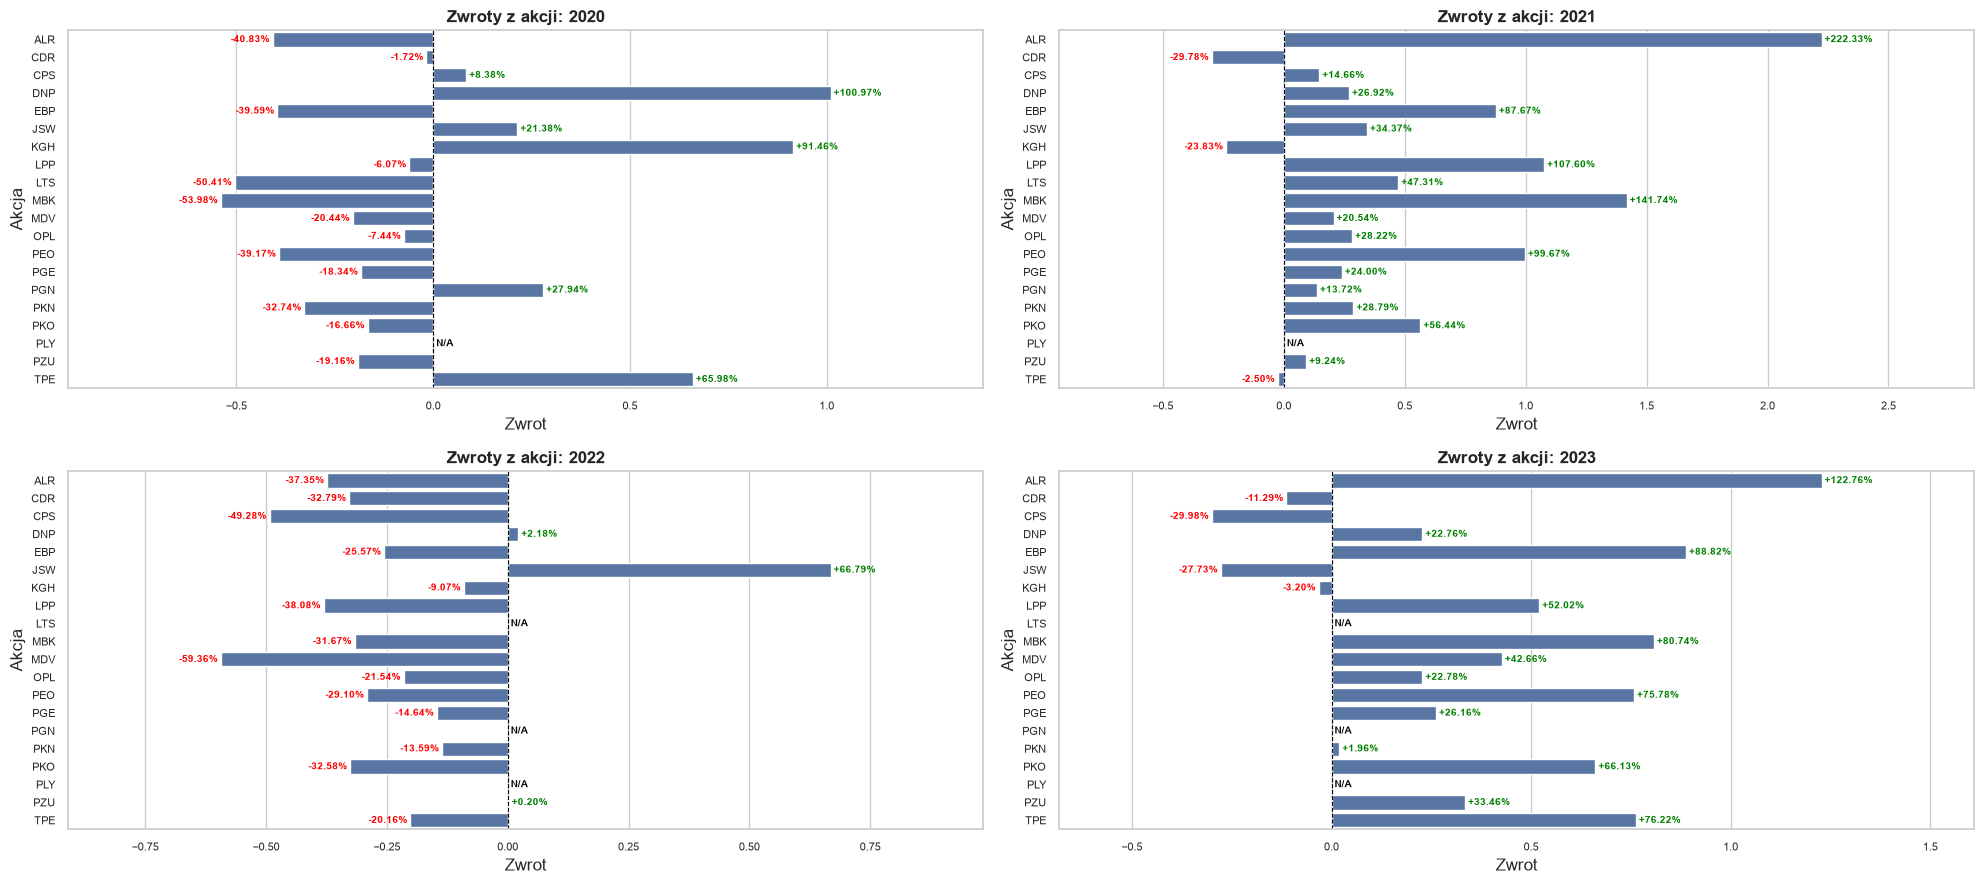

In [11]:
df = pd.read_parquet("results/processed_data/stock_data.parquet", engine="pyarrow")
df.index = pd.to_datetime(df.index)
df = df[(df.index >= TEST_START) & (df.index <= TEST_END)]

years = df.index.year.unique()
ncols = 2
nrows = (len(years) + ncols - 1) // ncols  # Calculate rows dynamically

# Adjust figure size for a compact layout (20 width, 4.5 height per row)
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4.5 * nrows))

# Flatten axes array for simple indexing regardless of grid dimensions
axes_flat = np.array(axes).flatten()

for i, year in enumerate(years):
    ax = axes_flat[i]

    # Filter out returns for the current year
    df_year = df.loc[str(year)]

    # Identify which assets contain NaNs in the current year
    has_nan = df_year.isna().any()

    # Calculate simple annual returns for valid assets
    valid_returns = np.exp(df_year.dropna(axis=1, how="any").sum()) - 1

    # Reindex so all 20 assets remain present in every subplot
    all_returns = valid_returns.reindex(df.columns)

    # Horizontal bar plot: assign values to x and asset names to y
    sns.barplot(x=all_returns.values, y=all_returns.index, ax=ax)

    # Add dynamically colored text labels for every bar
    for y_idx, val in enumerate(all_returns.values):
        if pd.isna(val):
            ax.text(
                0,
                y_idx,
                " N/A",
                va="center",
                ha="left",
                fontsize=7.5,
                color="black",
                fontweight="bold",
            )
        elif val >= 0:
            ax.text(
                val,
                y_idx,
                f" {val * 100:+.2f}%",
                va="center",
                ha="left",
                fontsize=7.5,
                color="green",
                fontweight="bold",
            )
        else:
            ax.text(
                val,
                y_idx,
                f"{val * 100:.2f}% ",
                va="center",
                ha="right",
                fontsize=7.5,
                color="red",
                fontweight="bold",
            )

    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Zwroty z akcji: {year}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Zwrot")
    ax.set_ylabel("Akcja")
    ax.tick_params(axis="both", labelsize=8)

    # Add horizontal padding to prevent outer labels from being cut off
    ax.margins(x=0.25)

# Remove any empty unused subplot slots in the final row
for j in range(len(years), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

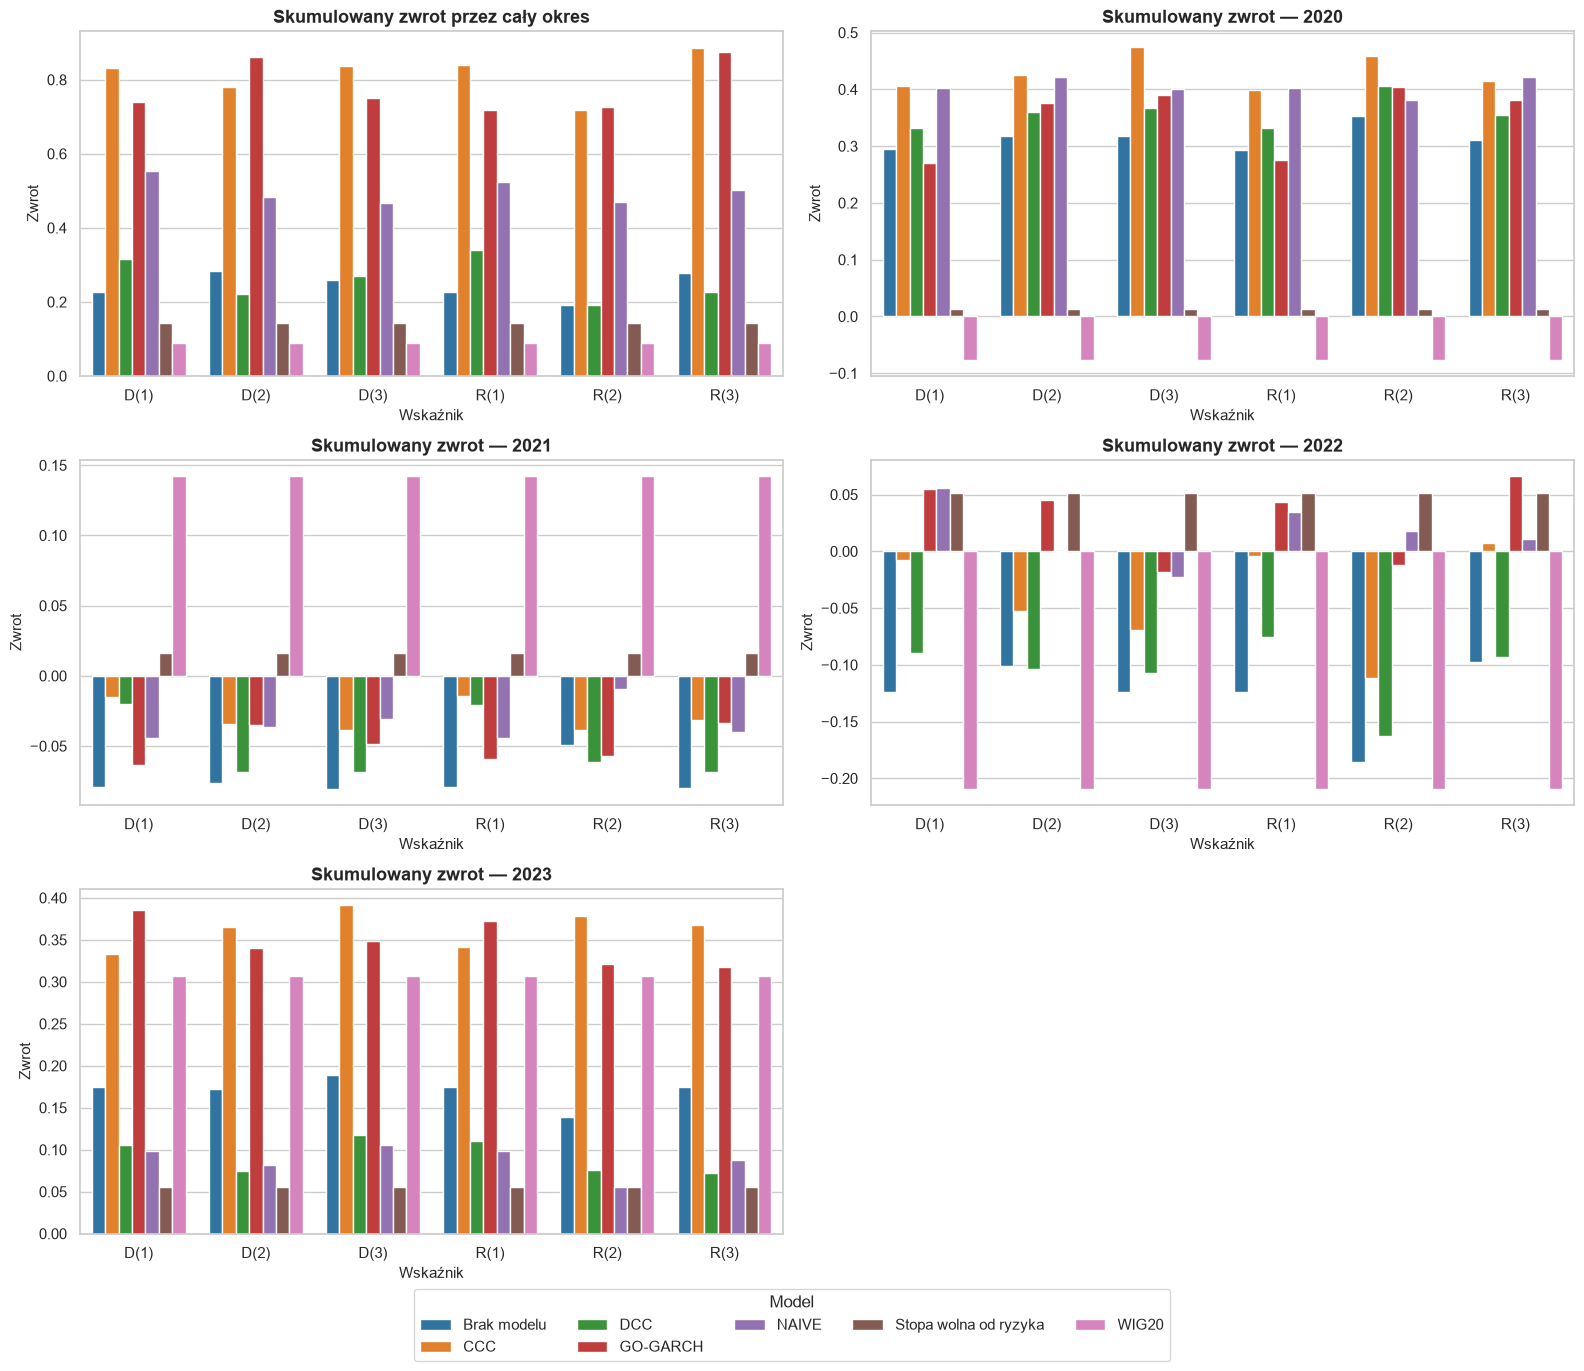

In [12]:
# Total cumulative return over the entire period
returns_overall = (
    final_df.groupby(["target_metric", "model"])["return"]
    .apply(lambda r: np.prod(1 + r) - 1)
    .reset_index(name="Total_Return")
)

# Annual cumulative returns by year
returns_annual = (
    final_df.groupby(["year", "target_metric", "model"])["return"]
    .apply(lambda r: np.prod(1 + r) - 1)
    .reset_index(name="Annual_Return")
)

# Setup plot grid layout
unique_years = sorted(returns_annual["year"].unique())
total_plots = len(unique_years) + 1
ncols = 2
nrows = math.ceil(total_plots / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4.5 * nrows))
axes = axes.flatten()

palette = "tab10"

# Entire period (Overall)
sns.barplot(
    data=returns_overall,
    x="target_metric",
    y="Total_Return",
    hue="model",
    palette=palette,
    ax=axes[0],
)
axes[0].set_title("Skumulowany zwrot przez cały okres", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Wskaźnik", fontsize=11)
axes[0].set_ylabel("Zwrot", fontsize=11)
axes[0].tick_params(axis="x")

# Extract handles/labels for the global legend, then remove the local legend
handles, labels = axes[0].get_legend_handles_labels()
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()

# Yearly breakdowns
for idx, year in enumerate(unique_years, start=1):
    year_data = returns_annual[returns_annual["year"] == year]
    sns.barplot(
        data=year_data,
        x="target_metric",
        y="Annual_Return",
        hue="model",
        palette=palette,
        ax=axes[idx],
        legend=False,
    )
    axes[idx].set_title(f"Skumulowany zwrot — {year}", fontsize=13, fontweight="bold")
    axes[idx].set_xlabel("Wskaźnik", fontsize=11)
    axes[idx].set_ylabel("Zwrot", fontsize=11)
    axes[idx].tick_params(axis="x")

# Delete unused subplot axes in the grid
for j in range(total_plots, len(axes)):
    fig.delaxes(axes[j])

# Add a single shared figure legend
fig.legend(
    handles,
    labels,
    title="Model",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=min(len(labels), 5),
    fontsize=11,
    title_fontsize=12,
    frameon=True,
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

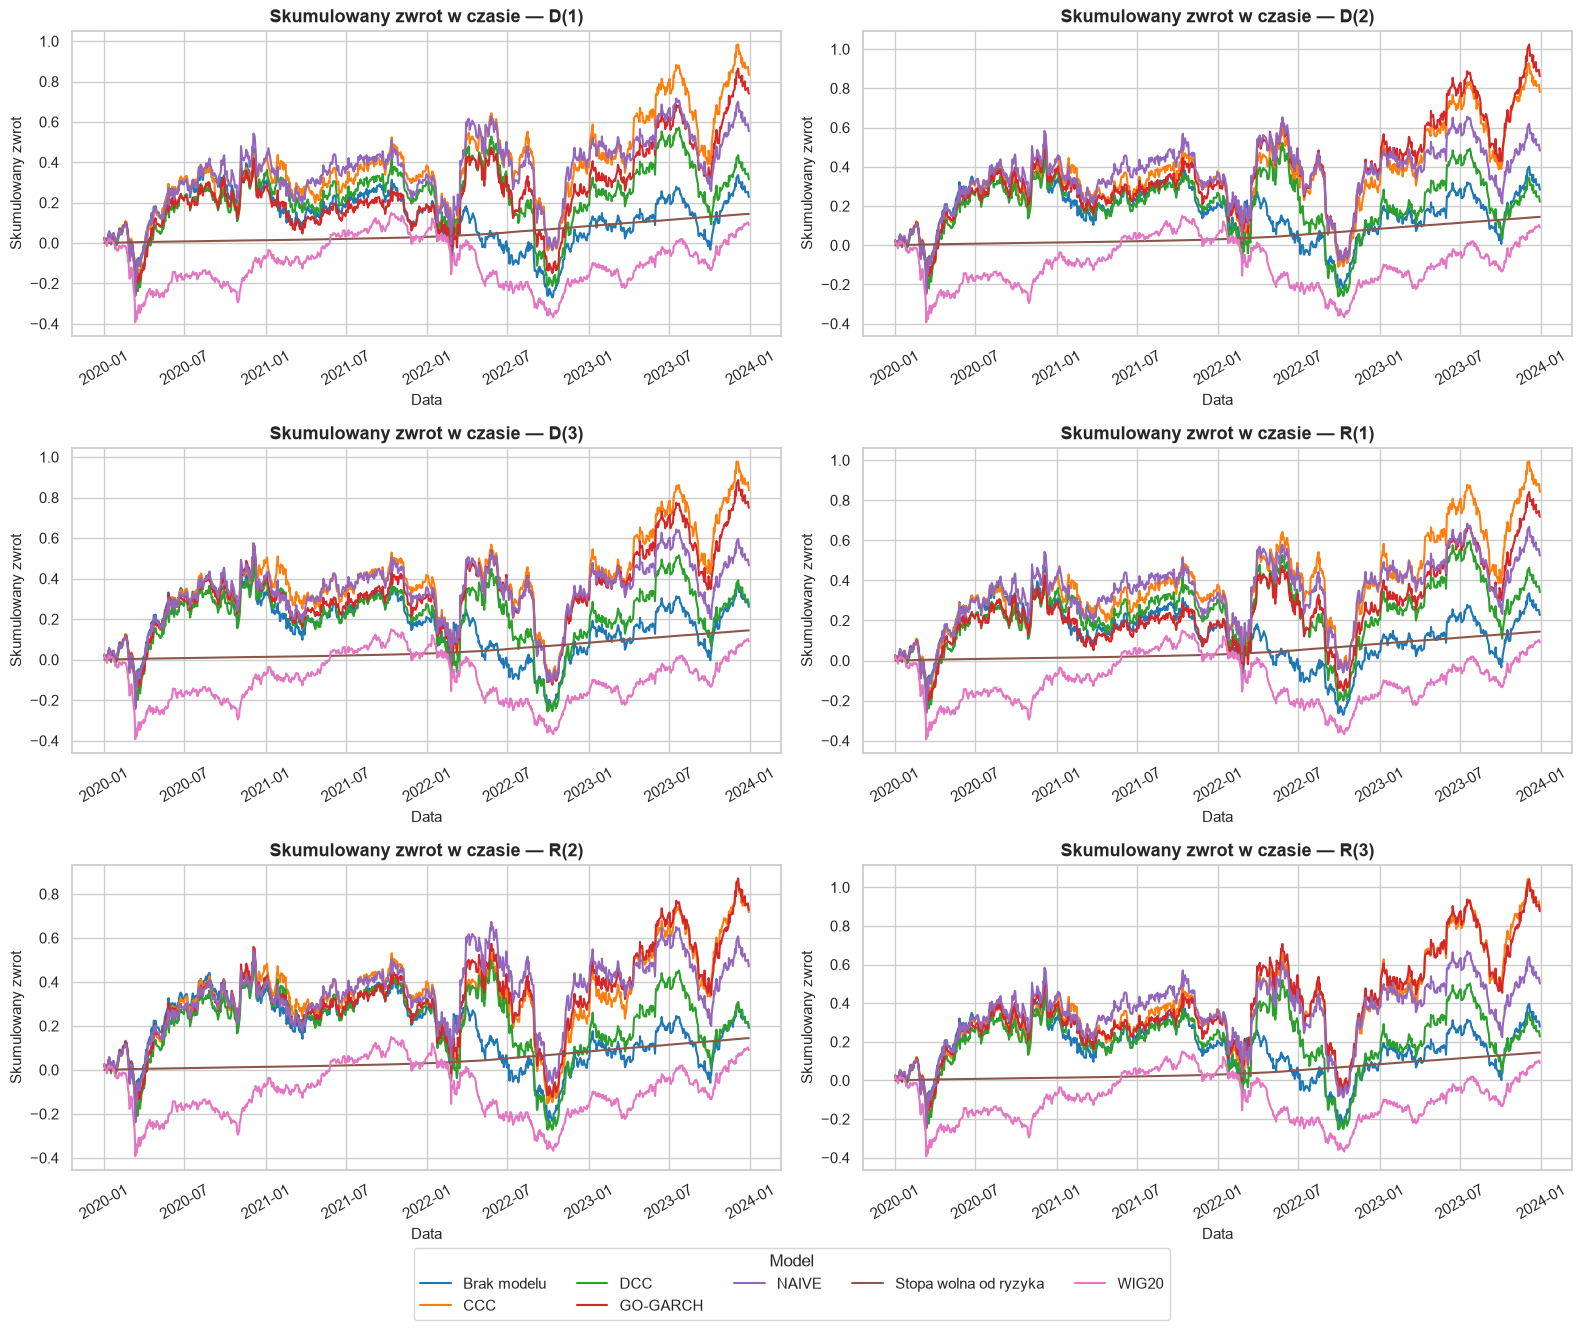

In [13]:
# Calculate daily cumulative returns for each metric and model combination
final_df = final_df.sort_values(by=["target_metric", "model", "date"])

# Setup grid layout based on unique target metrics
unique_metrics = sorted(final_df["target_metric"].unique())
total_plots = len(unique_metrics)
ncols = 2
nrows = math.ceil(total_plots / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4.5 * nrows))
axes = np.array(axes).flatten()

palette = "tab10"

# Create line plots for each metric
for idx, metric in enumerate(unique_metrics):
    metric_data = final_df[final_df["target_metric"] == metric]

    # Render lineplot; keep legend on the first plot only to extract handles
    sns.lineplot(
        data=metric_data,
        x="date",
        y="cum_return",
        hue="model",
        palette=palette,
        ax=axes[idx],
        legend=(idx == 0),
    )

    axes[idx].set_title(
        f"Skumulowany zwrot w czasie — {metric}",
        fontsize=13,
        fontweight="bold",
    )
    axes[idx].set_xlabel("Data", fontsize=11)
    axes[idx].set_ylabel("Skumulowany zwrot", fontsize=11)
    axes[idx].tick_params(axis="x", rotation=30)

# Extract handles/labels for the global legend, then remove the local legend
handles, labels = axes[0].get_legend_handles_labels()
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()

# Remove unused subplot axes in the grid
for j in range(total_plots, len(axes)):
    fig.delaxes(axes[j])

# Add single shared figure legend at the bottom
fig.legend(
    handles,
    labels,
    title="Model",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=min(len(labels), 5),
    fontsize=11,
    title_fontsize=12,
    frameon=True,
)

# Reserve space for the shared legend at the bottom
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

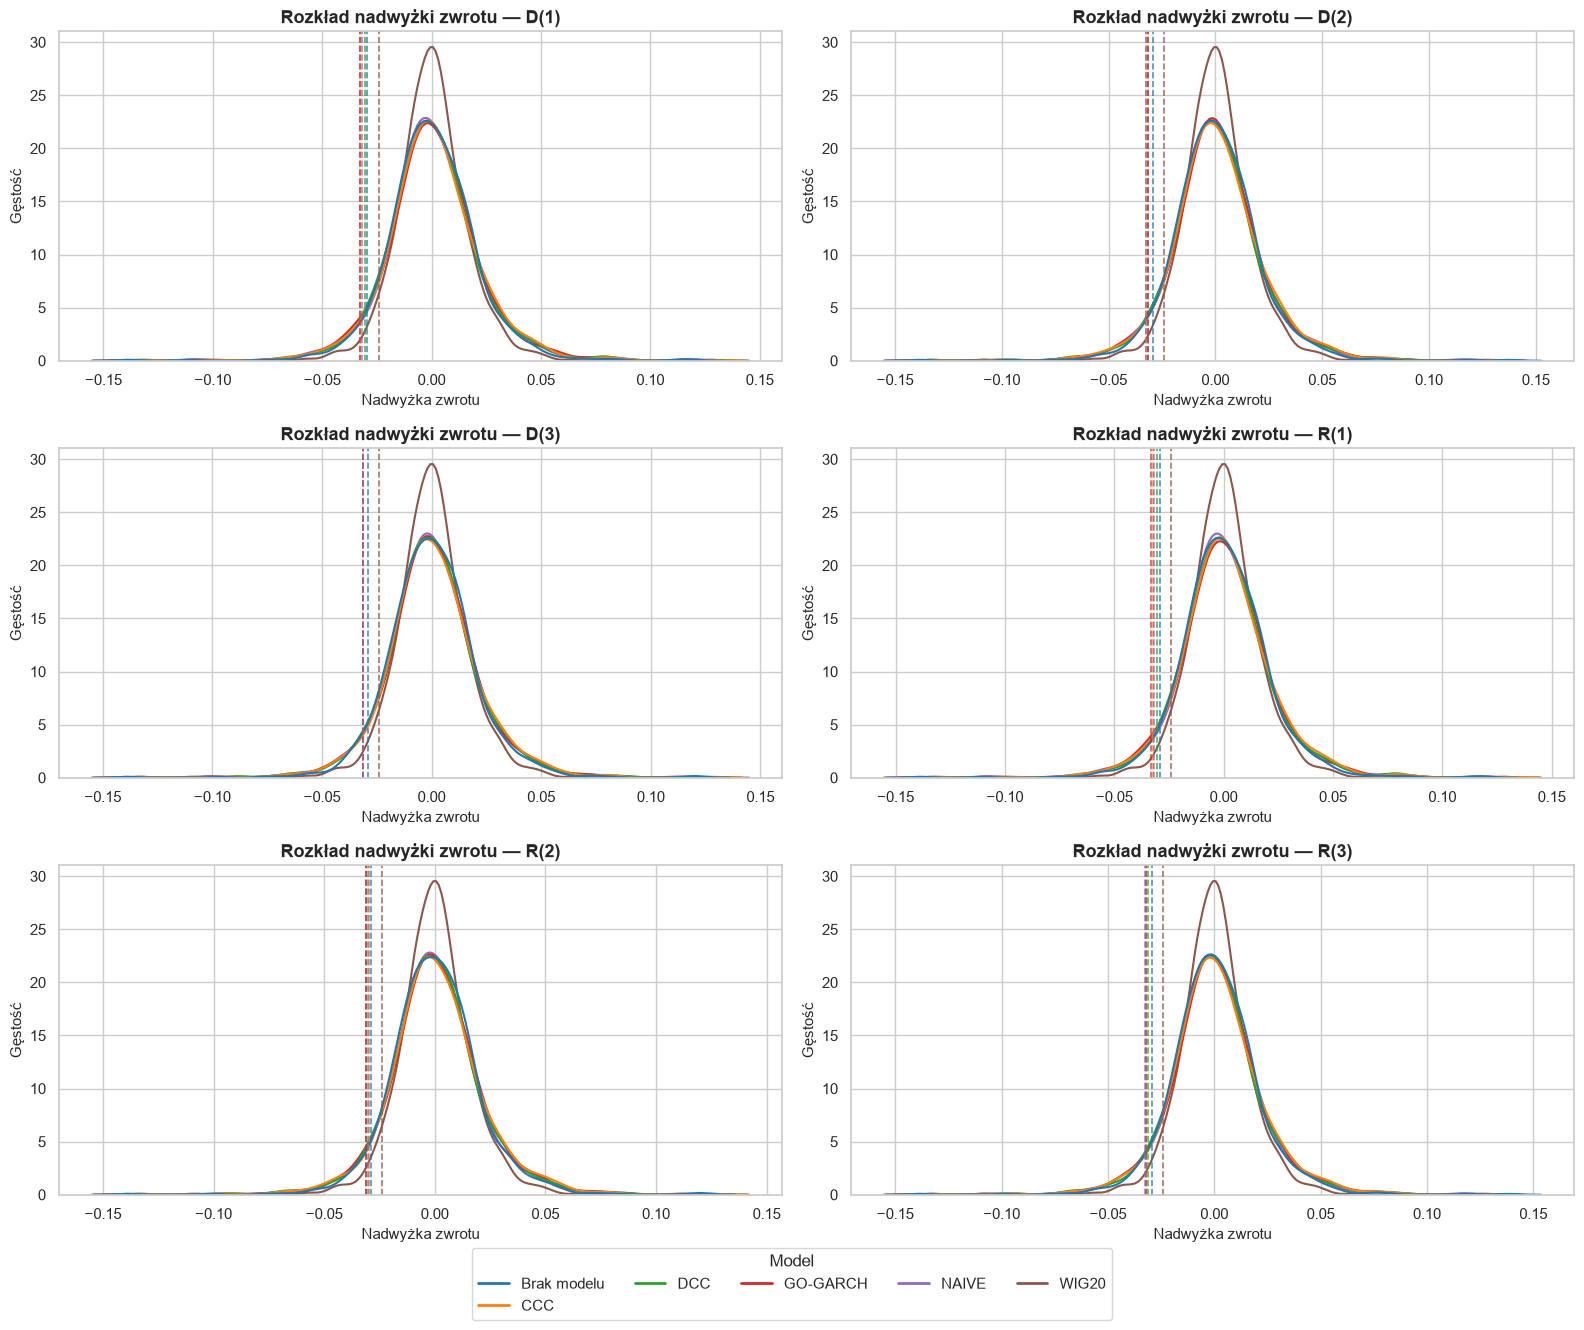

In [14]:
# Filter out risk free rate of return from the dataset
plot_df = final_df[final_df["model"] != "Stopa wolna od ryzyka"].copy()

# Setup grid layout based on unique target metrics and remaining models
unique_metrics = sorted(plot_df["target_metric"].unique())
unique_models = sorted(plot_df["model"].unique())

total_plots = len(unique_metrics)
ncols = 2
nrows = math.ceil(total_plots / ncols)

# Map remaining models to consistent colors across subplots
palette = sns.color_palette("tab10", n_colors=len(unique_models))
color_map = dict(zip(unique_models, palette, strict=True))

# Build explicit legend handles directly from color_map
legend_handles = [mlines.Line2D([], [], color=color_map[m], lw=2, label=m) for m in unique_models]

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4.5 * nrows), squeeze=False)
axes = axes.flatten()

# Iterate through each metric and plot KDE with 5% quantile lines
for idx, metric in enumerate(unique_metrics):
    metric_data = plot_df[plot_df["target_metric"] == metric]

    # Render KDE plot for each model
    sns.kdeplot(
        data=metric_data,
        x="excess_return",
        hue="model",
        palette=color_map,
        ax=axes[idx],
        common_norm=False,
        legend=False,
    )

    # Draw vertical lines for the 5% quantile (q05) per model
    for model_name in unique_models:
        sub_data = metric_data[metric_data["model"] == model_name]["excess_return"].dropna()
        if sub_data.empty:
            continue

        q05 = sub_data.quantile(0.05)
        c = color_map[model_name]

        # Draw 5% quantile vertical line (dashed)
        axes[idx].axvline(q05, color=c, linestyle="--", linewidth=1.2, alpha=0.8)

    axes[idx].set_title(
        f"Rozkład nadwyżki zwrotu — {metric}",
        fontsize=13,
        fontweight="bold",
    )
    axes[idx].set_xlabel("Nadwyżka zwrotu", fontsize=11)
    axes[idx].set_ylabel("Gęstość", fontsize=11)

# Delete unused subplot axes in the current grid
for j in range(total_plots, len(axes)):
    fig.delaxes(axes[j])

# Add a single shared figure legend at the bottom using explicit handles
fig.legend(
    handles=legend_handles,
    labels=unique_models,
    title="Model",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=min(len(unique_models), 5),
    fontsize=11,
    title_fontsize=12,
    frameon=True,
)

# Adjust layout spacing to accommodate the legend
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## General Summary

This section focuses on summarizing all the main results in a few tables.

In [15]:
def format_val(val):
    return "—" if pd.isna(val) else f"{val:.6f}".replace(".", ",")


final_df["year"] = final_df["date"].dt.year
unique_years = sorted(final_df["year"].unique())

year_chunks = [unique_years[i : i + 2] for i in range(0, len(unique_years), 2)]

period_tables = {}

for years in year_chunks:
    period_label = f"{years[0]}-{years[-1]}" if len(years) > 1 else str(years[0])
    period_df = final_df[final_df["year"].isin(years)].copy()

    # Define custom aggregation logic for grouped data
    def aggregate_metrics(group: pd.DataFrame) -> pd.Series:
        metric_name = METRIC_MAPPING_SUMMARY[group.name[0]]
        excess_ret = group["excess_return"].dropna()
        turnover = group["turnover"].dropna()
        ret = group["return"].dropna()

        cum_return = (1 + ret).prod() - 1
        mean_excess = excess_ret.mean()
        std_excess = excess_ret.std(ddof=1)
        mean_turnover = turnover.mean()

        return pd.Series(
            {
                "Zwrot": cum_return,
                "Średnia nadwyżka": mean_excess,
                "Zmienność": std_excess,
                "Obrót": mean_turnover,
                "ES": expected_shortfall(excess_ret),
                "Metryka": compute_metric(excess_ret, metric_name)
                if group.name[1] != "Stopa wolna od ryzyka"
                else np.nan,
            }
        )

    # Group by target_metric (1st level) and model (2nd level)
    summary_table = period_df.groupby(["target_metric", "model"]).apply(aggregate_metrics, include_groups=False)
    summary_table.index.names = ["", "Model"]
    summary_table = summary_table.map(format_val)

    period_tables[period_label] = summary_table

for period_label, table in period_tables.items():
    print(f"Data for period: {period_label}")
    display(table)
    print(table.to_latex(index=True))

Data for period: 2020-2021


Zwrot Średnia nadwyżka Zmienność     Obrót  \
     Model                                                                  
D(1) Brak modelu            0,191786         0,000505  0,020728  0,077458   
     CCC                    0,384436         0,000785  0,019816  0,176486   
     DCC                    0,306035         0,000664  0,019588  0,159266   
     GO-GARCH               0,190290         0,000504  0,020832  0,286244   
     NAIVE                  0,340382         0,000739  0,020768  0,076723   
     Stopa wolna od ryzyka  0,030237         0,000000  0,000000         —   
     WIG20                  0,054337         0,000185  0,016565         —   
D(2) Brak modelu            0,216855         0,000543  0,020553  0,062392   
     CCC                    0,377182         0,000772  0,019665  0,153186   
     DCC                    0,268097         0,000607  0,019655  0,145349   
     GO-GARCH               0,328335         0,000717  0,020553  0,243758   
     NAIVE                  0,371230         0,000781  0,020611  0,067977   
     Stopa wolna od ryzyka  0,030237         0,000000  0,000000         —   
     WIG20                  0,054337         0,000185  0,016565         —   
D(3) Brak modelu            0,210851         0,000531  0,020485  0,064563   
     CCC                    0,418113         0,000825  0,019444  0,152903   
     DCC                    0,274404         0,000612  0,019409  0,147150   
     GO-GARCH               0,321557         0,000705  0,020472  0,236880   
     NAIVE                  0,356733         0,000758  0,020498  0,067908   
     Stopa wolna od ryzyka  0,030237         0,000000  0,000000         —   
     WIG20                  0,054337         0,000185  0,016565         —   
R(1) Brak modelu            0,191177         0,000504  0,020725  0,077760   
     CCC                    0,378333         0,000776  0,019800  0,176211   
     DCC                    0,305149         0,000663  0,019588  0,159083   
     GO-GARCH               0,199817         0,000521  0,020853  0,287623   
     NAIVE                  0,340660         0,000740  0,020768  0,076706   
     Stopa wolna od ryzyka  0,030237         0,000000  0,000000         —   
     WIG20                  0,054337         0,000185  0,016565         —   
R(2) Brak modelu            0,286339         0,000644  0,020128  0,066038   
     CCC                    0,402430         0,000802  0,019378  0,158650   
     DCC                    0,320397         0,000683  0,019447  0,148030   
     GO-GARCH               0,323753         0,000705  0,020304  0,233350   
     NAIVE                  0,368728         0,000767  0,020076  0,067947   
     Stopa wolna od ryzyka  0,030237         0,000000  0,000000         —   
     WIG20                  0,054337         0,000185  0,016565         —   
R(3) Brak modelu            0,205925         0,000525  0,020578  0,063593   
     CCC                    0,369666         0,000762  0,019711  0,153685   
     DCC                    0,262481         0,000599  0,019679  0,145518   
     GO-GARCH               0,334918         0,000727  0,020565  0,245543   
     NAIVE                  0,365803         0,000774  0,020641  0,068776   
     Stopa wolna od ryzyka  0,030237         0,000000  0,000000         —   
     WIG20                  0,054337         0,000185  0,016565         —   

                                   ES   Metryka  
     Model                                       
D(1) Brak modelu             0,045530  0,010963  
     CCC                     0,044242  0,017429  
     DCC                     0,043565  0,015019  
     GO-GARCH                0,046707  0,010683  
     NAIVE                   0,046011  0,015813  
     Stopa wolna od ryzyka  -0,000000         —  
     WIG20                   0,039781  0,004622  
D(2) Brak modelu             0,044803  0,037638  
     CCC                     0,043827  0,054893  
     DCC                     0,043522  0,043352  
     GO-GARCH                0,045521  0,0

\begin{tabular}{llllllll}
\toprule
 &  & Zwrot & Średnia nadwyżka & Zmienność & Obrót & ES & Metryka \\
 & Model &  &  &  &  &  &  \\
\midrule
\multirow[t]{7}{*}{D(1)} & Brak modelu & 0,191786 & 0,000505 & 0,020728 & 0,077458 & 0,045530 & 0,010963 \\
 & CCC & 0,384436 & 0,000785 & 0,019816 & 0,176486 & 0,044242 & 0,017429 \\
 & DCC & 0,306035 & 0,000664 & 0,019588 & 0,159266 & 0,043565 & 0,015019 \\
 & GO-GARCH & 0,190290 & 0,000504 & 0,020832 & 0,286244 & 0,046707 & 0,010683 \\
 & NAIVE & 0,340382 & 0,000739 & 0,020768 & 0,076723 & 0,046011 & 0,015813 \\
 & Stopa wolna od ryzyka & 0,030237 & 0,000000 & 0,000000 & — & -0,000000 & — \\
 & WIG20 & 0,054337 & 0,000185 & 0,016565 & — & 0,039781 & 0,004622 \\
\cline{1-8}
\multirow[t]{7}{*}{D(2)} & Brak modelu & 0,216855 & 0,000543 & 0,020553 & 0,062392 & 0,044803 & 0,037638 \\
 & CCC & 0,377182 & 0,000772 & 0,019665 & 0,153186 & 0,043827 & 0,054893 \\
 & DCC & 0,268097 & 0,000607 & 0,019655 & 0,145349 & 0,043522 & 0,043352 \\
 & GO-GARCH & 

Zwrot Średnia nadwyżka Zmienność     Obrót  \
     Model                                                                   
D(1) Brak modelu             0,029895         0,000049  0,020012  0,119524   
     CCC                     0,323226         0,000627  0,023628  0,811456   
     DCC                     0,006734         0,000079  0,023538  0,697044   
     GO-GARCH                0,461549         0,000814  0,023119  0,890390   
     NAIVE                   0,159234         0,000349  0,023036  0,787025   
     Stopa wolna od ryzyka   0,110679         0,000000  0,000000         —   
     WIG20                   0,033557        -0,000005  0,016664         —   
D(2) Brak modelu             0,053977         0,000100  0,020340  0,122448   
     CCC                     0,292869         0,000588  0,023938  0,839572   
     DCC                    -0,036662        -0,000006  0,023654  0,717745   
     GO-GARCH                0,401770         0,000734  0,023250  0,924719   
     NAIVE                   0,080949         0,000212  0,023137  0,819043   
     Stopa wolna od ryzyka   0,110679         0,000000  0,000000         —   
     WIG20                   0,033557        -0,000005  0,016664         —   
D(3) Brak modelu             0,040870         0,000063  0,019717  0,123009   
     CCC                     0,294599         0,000571  0,023097  0,831246   
     DCC                    -0,002725         0,000044  0,022834  0,717240   
     GO-GARCH                0,323970         0,000606  0,022643  0,912508   
     NAIVE                   0,080360         0,000196  0,022448  0,811835   
     Stopa wolna od ryzyka   0,110679         0,000000  0,000000         —   
     WIG20                   0,033557        -0,000005  0,016664         —   
R(1) Brak modelu             0,029895         0,000049  0,020012  0,119524   
     CCC                     0,335632         0,000650  0,023829  0,814328   
     DCC                     0,027389         0,000119  0,023511  0,699794   
     GO-GARCH                0,431504         0,000774  0,023172  0,890715   
     NAIVE                   0,136375         0,000305  0,022823  0,785977   
     Stopa wolna od ryzyka   0,110679         0,000000  0,000000         —   
     WIG20                   0,033557        -0,000005  0,016664         —   
R(2) Brak modelu            -0,072614        -0,000161  0,020037  0,137053   
     CCC                     0,224711         0,000473  0,023654  0,850157   
     DCC                    -0,098445        -0,000149  0,023191  0,737908   
     GO-GARCH                0,304899         0,000583  0,022940  0,946068   
     NAIVE                   0,074552         0,000192  0,022770  0,827662   
     Stopa wolna od ryzyka   0,110679         0,000000  0,000000         —   
     WIG20                   0,033557        -0,000005  0,016664         —   
R(3) Brak modelu             0,059895         0,000113  0,020392  0,122588   
     CCC                     0,377580         0,000716  0,023999  0,842936   
     DCC                    -0,028061         0,000005  0,023382  0,717189   
     GO-GARCH                0,405403         0,000745  0,023539  0,922586   
     NAIVE                   0,099236         0,000247  0,023204  0,822201   
     Stopa wolna od ryzyka   0,110679         0,000000  0,000000         —   
     WIG20                   0,033557        -0,000005  0,016664         —   

                                   ES    Metryka  
     Model                                        
D(1) Brak modelu             0,041072   0,001183  
     CCC                     0,049258   0,012571  
     DCC                     0,048860   0,001613  
     GO-GARCH                0,047423   0,016871  
     NAIVE                   0,048287   0,007182  
     Stopa wolna od ryzyka  -0,000000          —  
     WIG20                   0,033603  -0,000000  
D(2) Brak modelu             0,040634   0,007357  
     CCC                     0,050717   0,036024  
     DCC                     0,050073 

\begin{tabular}{llllllll}
\toprule
 &  & Zwrot & Średnia nadwyżka & Zmienność & Obrót & ES & Metryka \\
 & Model &  &  &  &  &  &  \\
\midrule
\multirow[t]{7}{*}{D(1)} & Brak modelu & 0,029895 & 0,000049 & 0,020012 & 0,119524 & 0,041072 & 0,001183 \\
 & CCC & 0,323226 & 0,000627 & 0,023628 & 0,811456 & 0,049258 & 0,012571 \\
 & DCC & 0,006734 & 0,000079 & 0,023538 & 0,697044 & 0,048860 & 0,001613 \\
 & GO-GARCH & 0,461549 & 0,000814 & 0,023119 & 0,890390 & 0,047423 & 0,016871 \\
 & NAIVE & 0,159234 & 0,000349 & 0,023036 & 0,787025 & 0,048287 & 0,007182 \\
 & Stopa wolna od ryzyka & 0,110679 & 0,000000 & 0,000000 & — & -0,000000 & — \\
 & WIG20 & 0,033557 & -0,000005 & 0,016664 & — & 0,033603 & -0,000000 \\
\cline{1-8}
\multirow[t]{7}{*}{D(2)} & Brak modelu & 0,053977 & 0,000100 & 0,020340 & 0,122448 & 0,040634 & 0,007357 \\
 & CCC & 0,292869 & 0,000588 & 0,023938 & 0,839572 & 0,050717 & 0,036024 \\
 & DCC & -0,036662 & -0,000006 & 0,023654 & 0,717745 & 0,050073 & -0,000000 \\
 & GO-GAR

## Turnover

This section focuses on turnover for different metrics and models to determine both the stability of the portfolio and the possibility of extra transaction costs.

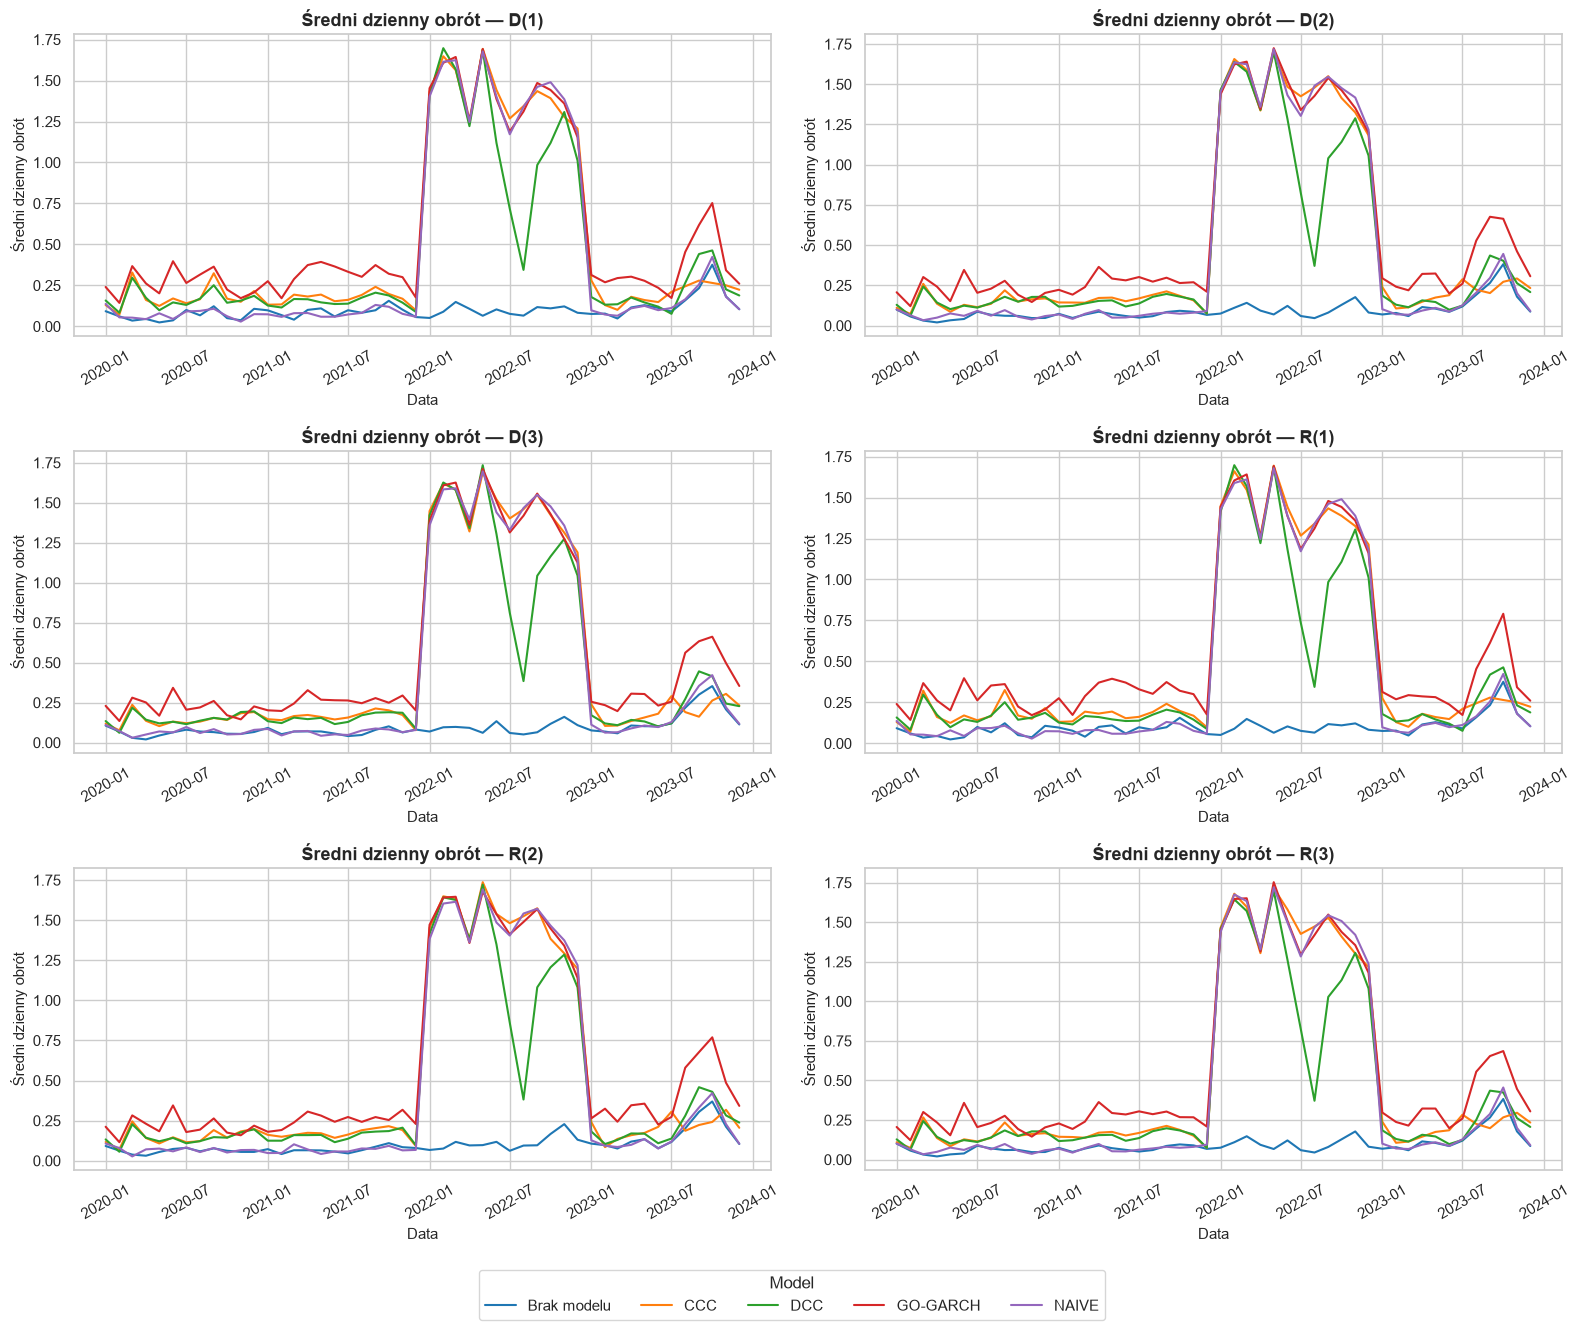

In [16]:
# Filter out models without turnover data
turnover_df = final_df[final_df["turnover"].notna()].copy()

# Create a monthly timestamp column for plotting on the time axis
turnover_df["year_month"] = turnover_df["date"].dt.to_period("M").dt.to_timestamp()

# Calculate average daily turnover per month for each metric and model
monthly_avg_turnover = (
    turnover_df.groupby(["target_metric", "model", "year_month"])["turnover"]
    .mean()
    .reset_index(name="avg_daily_turnover")
)

# Setup grid layout based on unique target metrics
unique_metrics = sorted(monthly_avg_turnover["target_metric"].unique())
total_plots = len(unique_metrics)
ncols = 2
nrows = math.ceil(total_plots / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4.5 * nrows))
axes = np.array(axes).flatten()

palette = "tab10"

# Create line plots for each target metric
for idx, metric in enumerate(unique_metrics):
    metric_data = monthly_avg_turnover[monthly_avg_turnover["target_metric"] == metric]

    # Render lineplot; keep legend on the first plot only to extract handles
    sns.lineplot(
        data=metric_data,
        x="year_month",
        y="avg_daily_turnover",
        hue="model",
        palette=palette,
        ax=axes[idx],
        legend=(idx == 0),
    )

    axes[idx].set_title(
        f"Średni dzienny obrót — {metric}",
        fontsize=13,
        fontweight="bold",
    )
    axes[idx].set_xlabel("Data", fontsize=11)
    axes[idx].set_ylabel("Średni dzienny obrót", fontsize=11)
    axes[idx].tick_params(axis="x", rotation=30)

# Extract handles/labels for the global legend, then remove the local legend
handles, labels = axes[0].get_legend_handles_labels()
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()

# Remove unused subplot axes in the grid
for j in range(total_plots, len(axes)):
    fig.delaxes(axes[j])

# Add single shared figure legend at the bottom
fig.legend(
    handles,
    labels,
    title="Model",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=min(len(labels), 5),
    fontsize=11,
    title_fontsize=12,
    frameon=True,
)

# Reserve space for the shared legend at the bottom
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## Industry Allocation

This section focuses on how the portfolio weights are distributed across industries and how it changes over time.

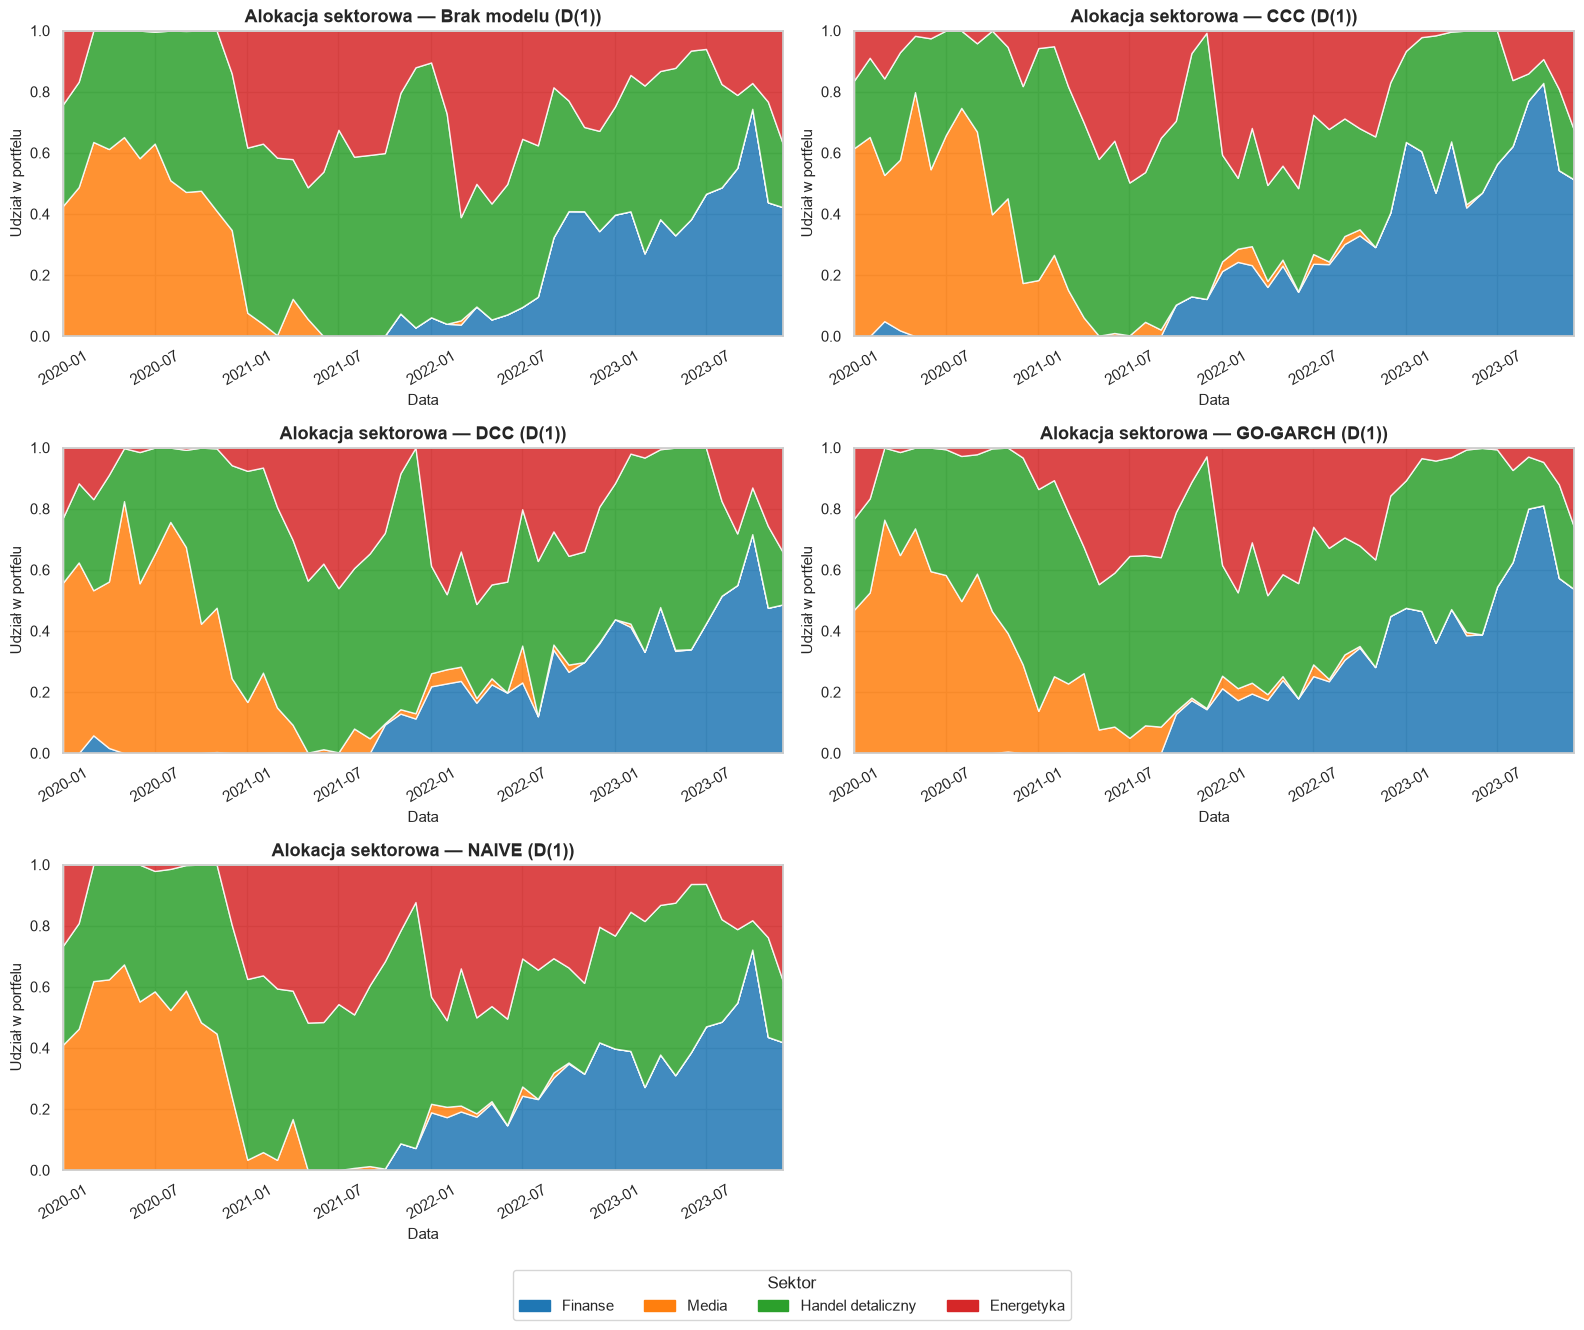

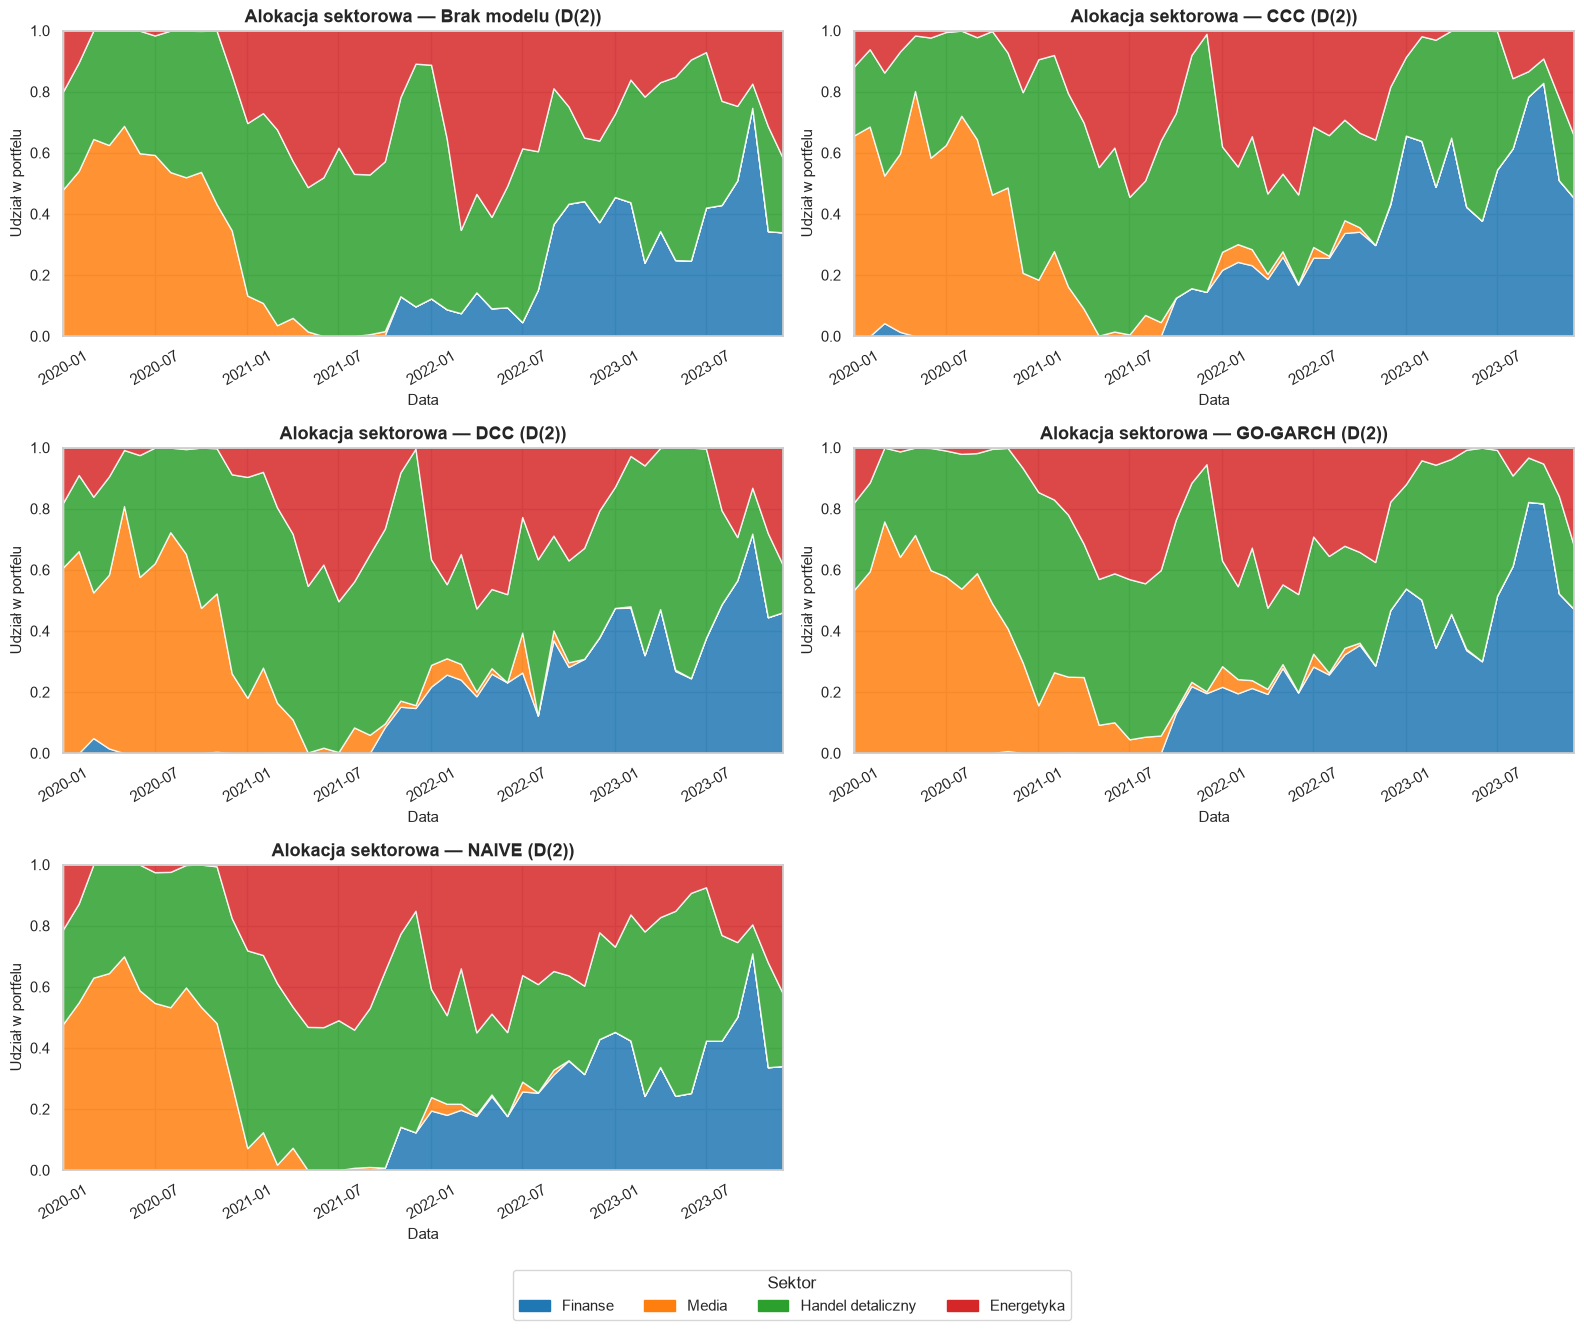

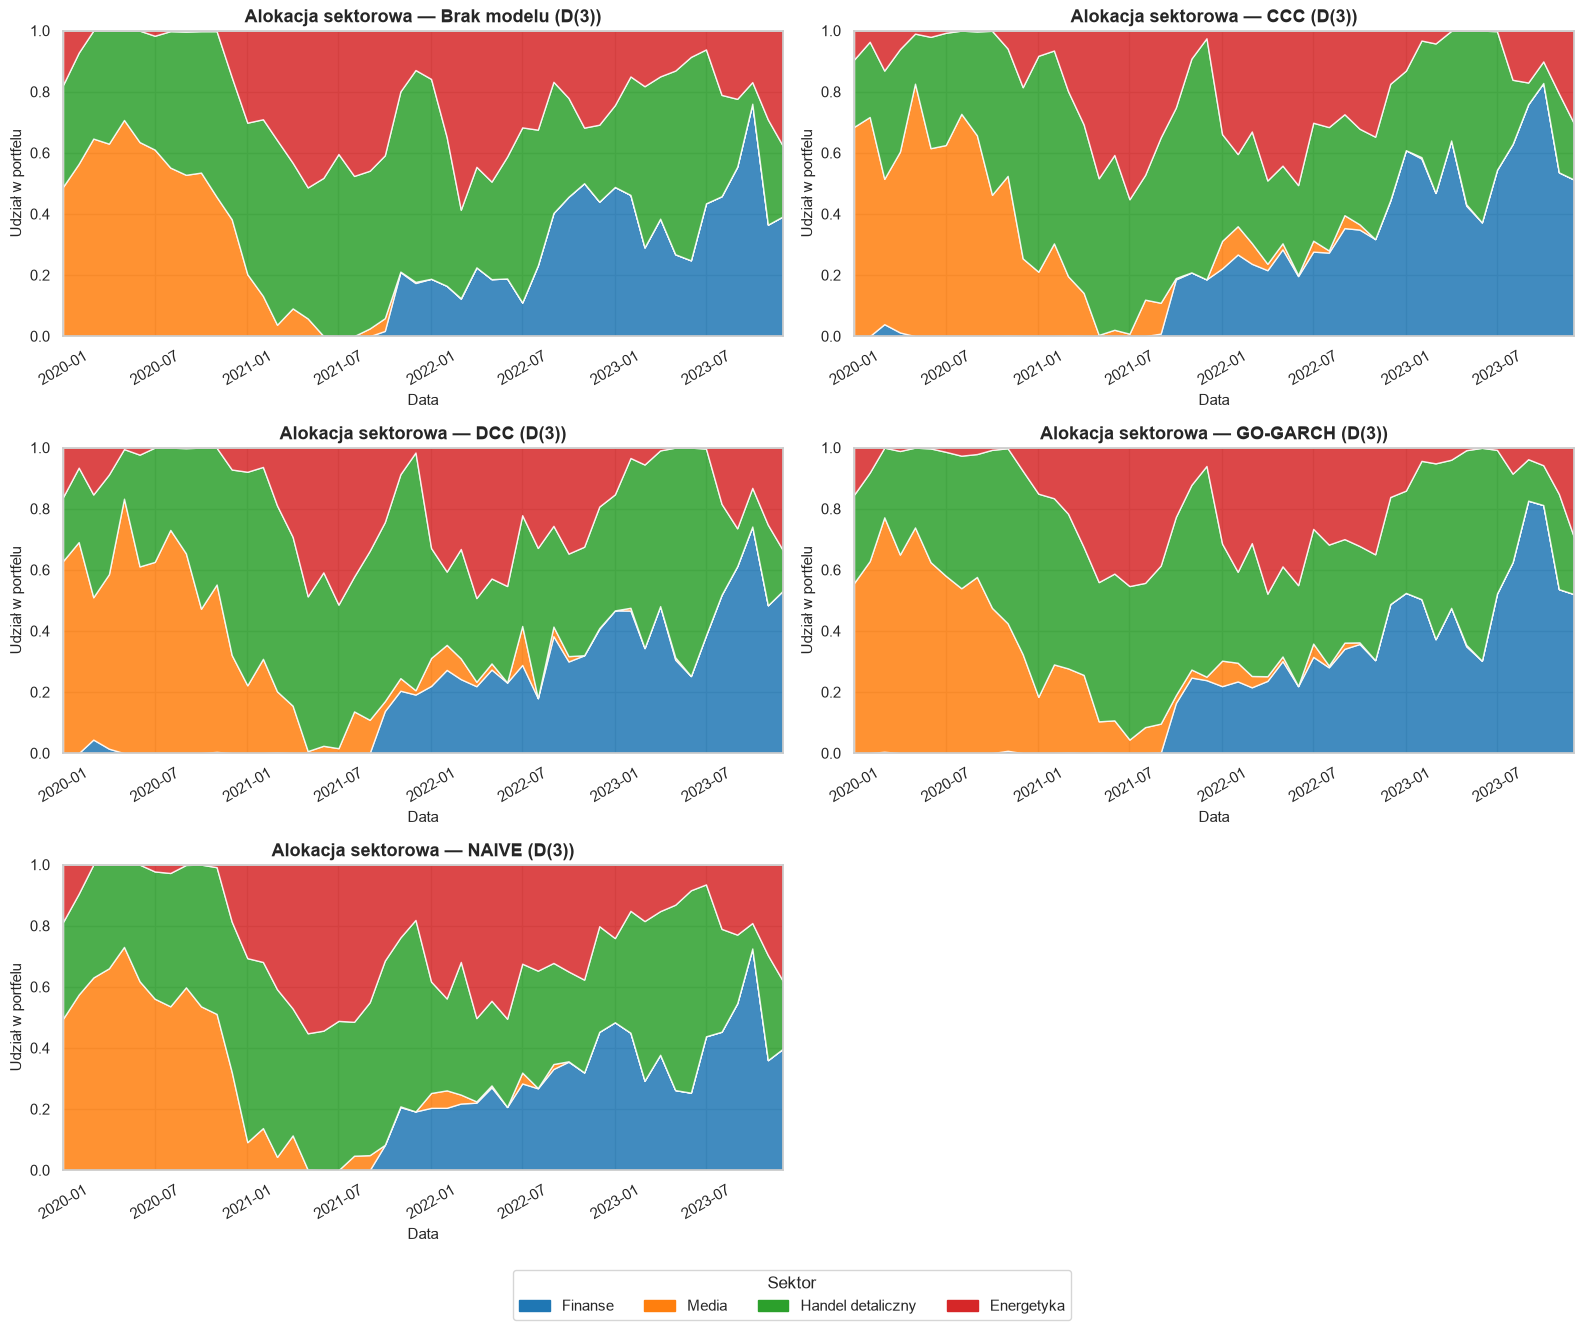

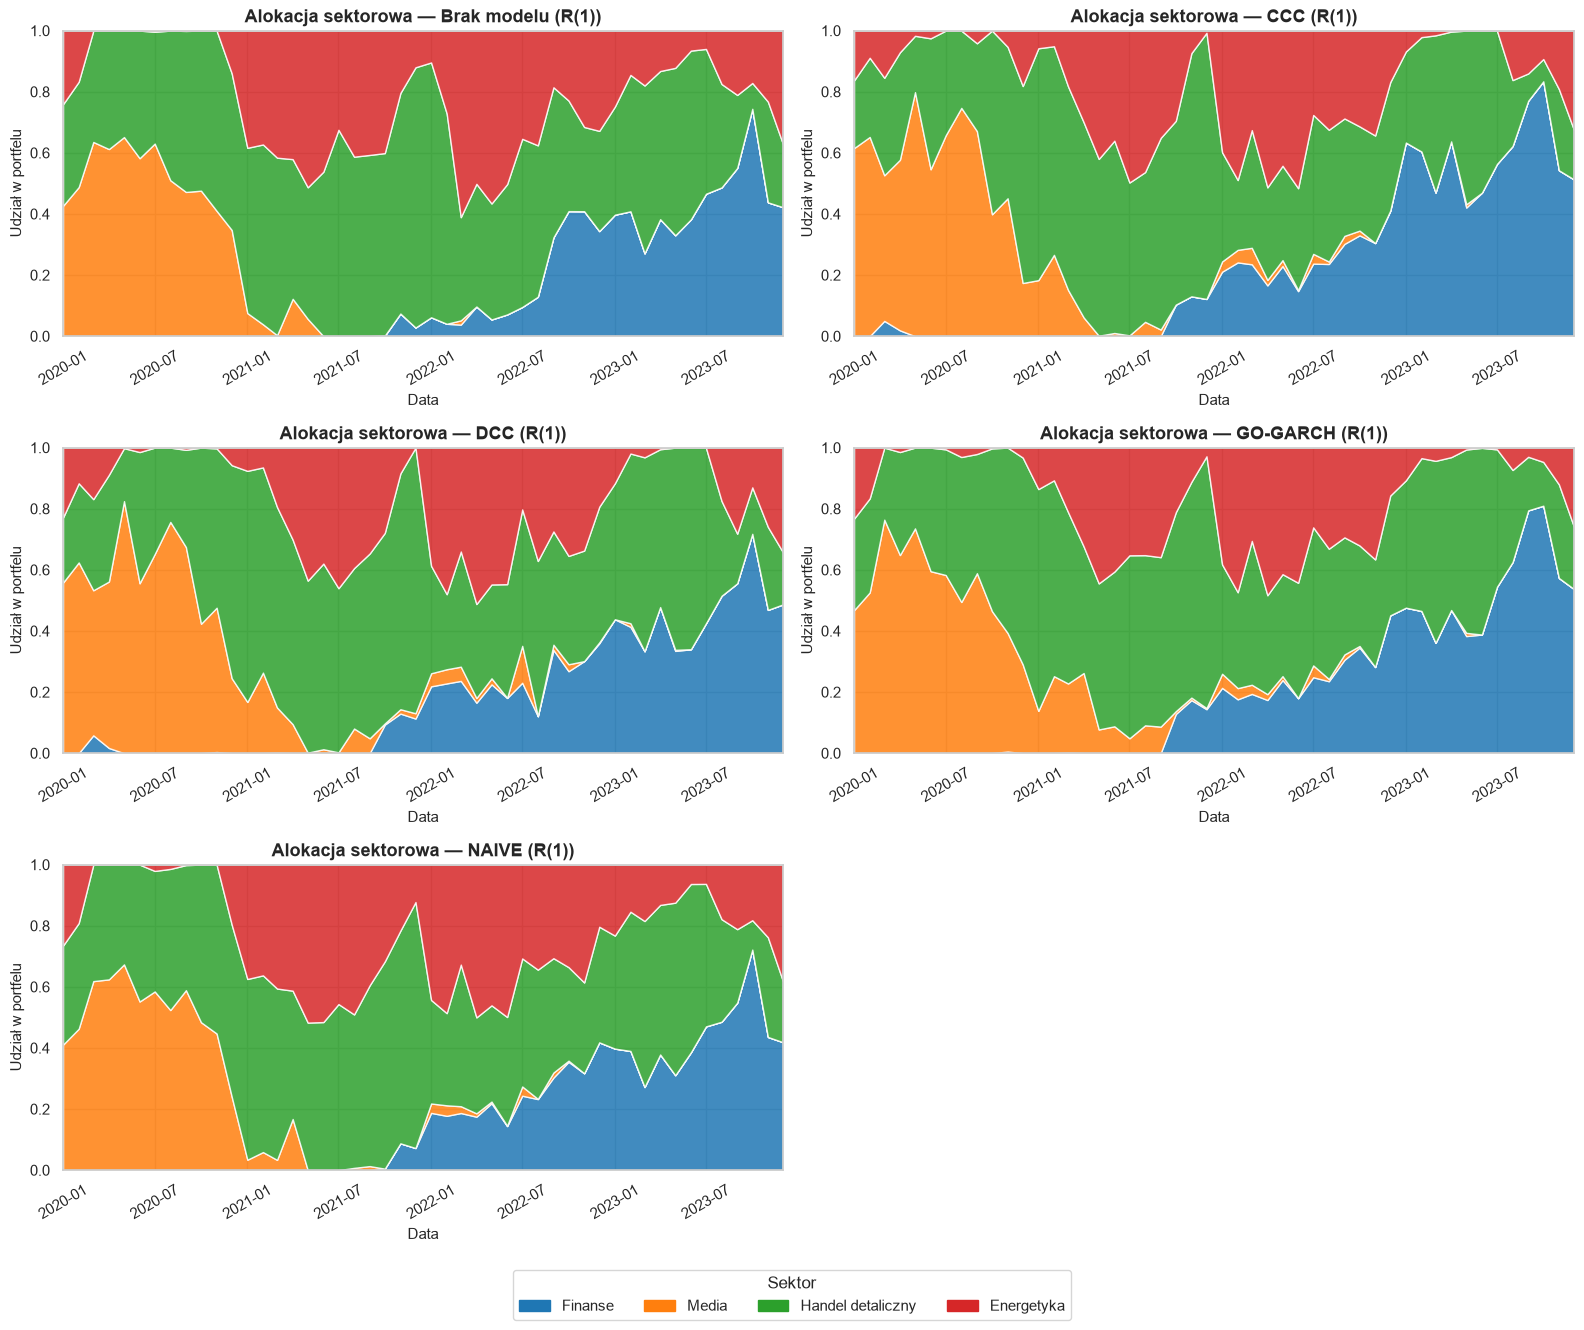

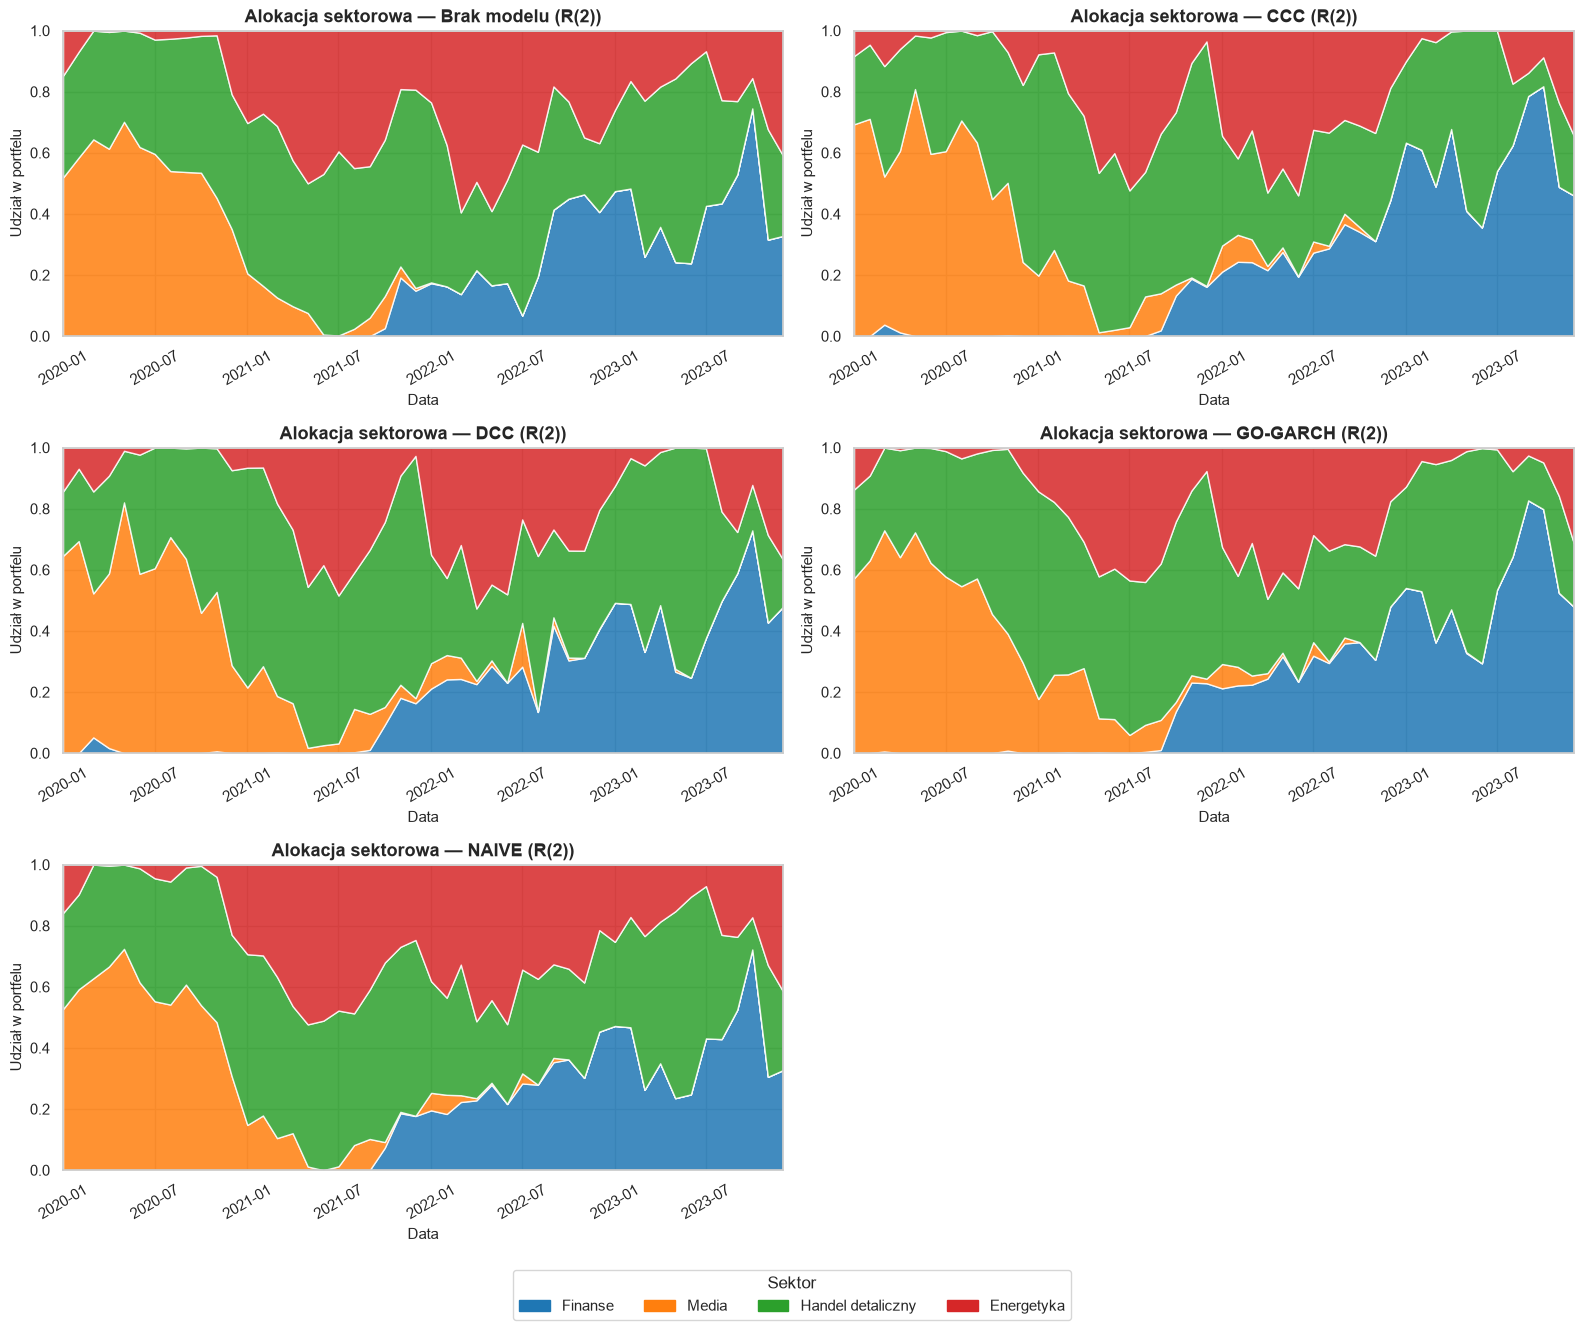

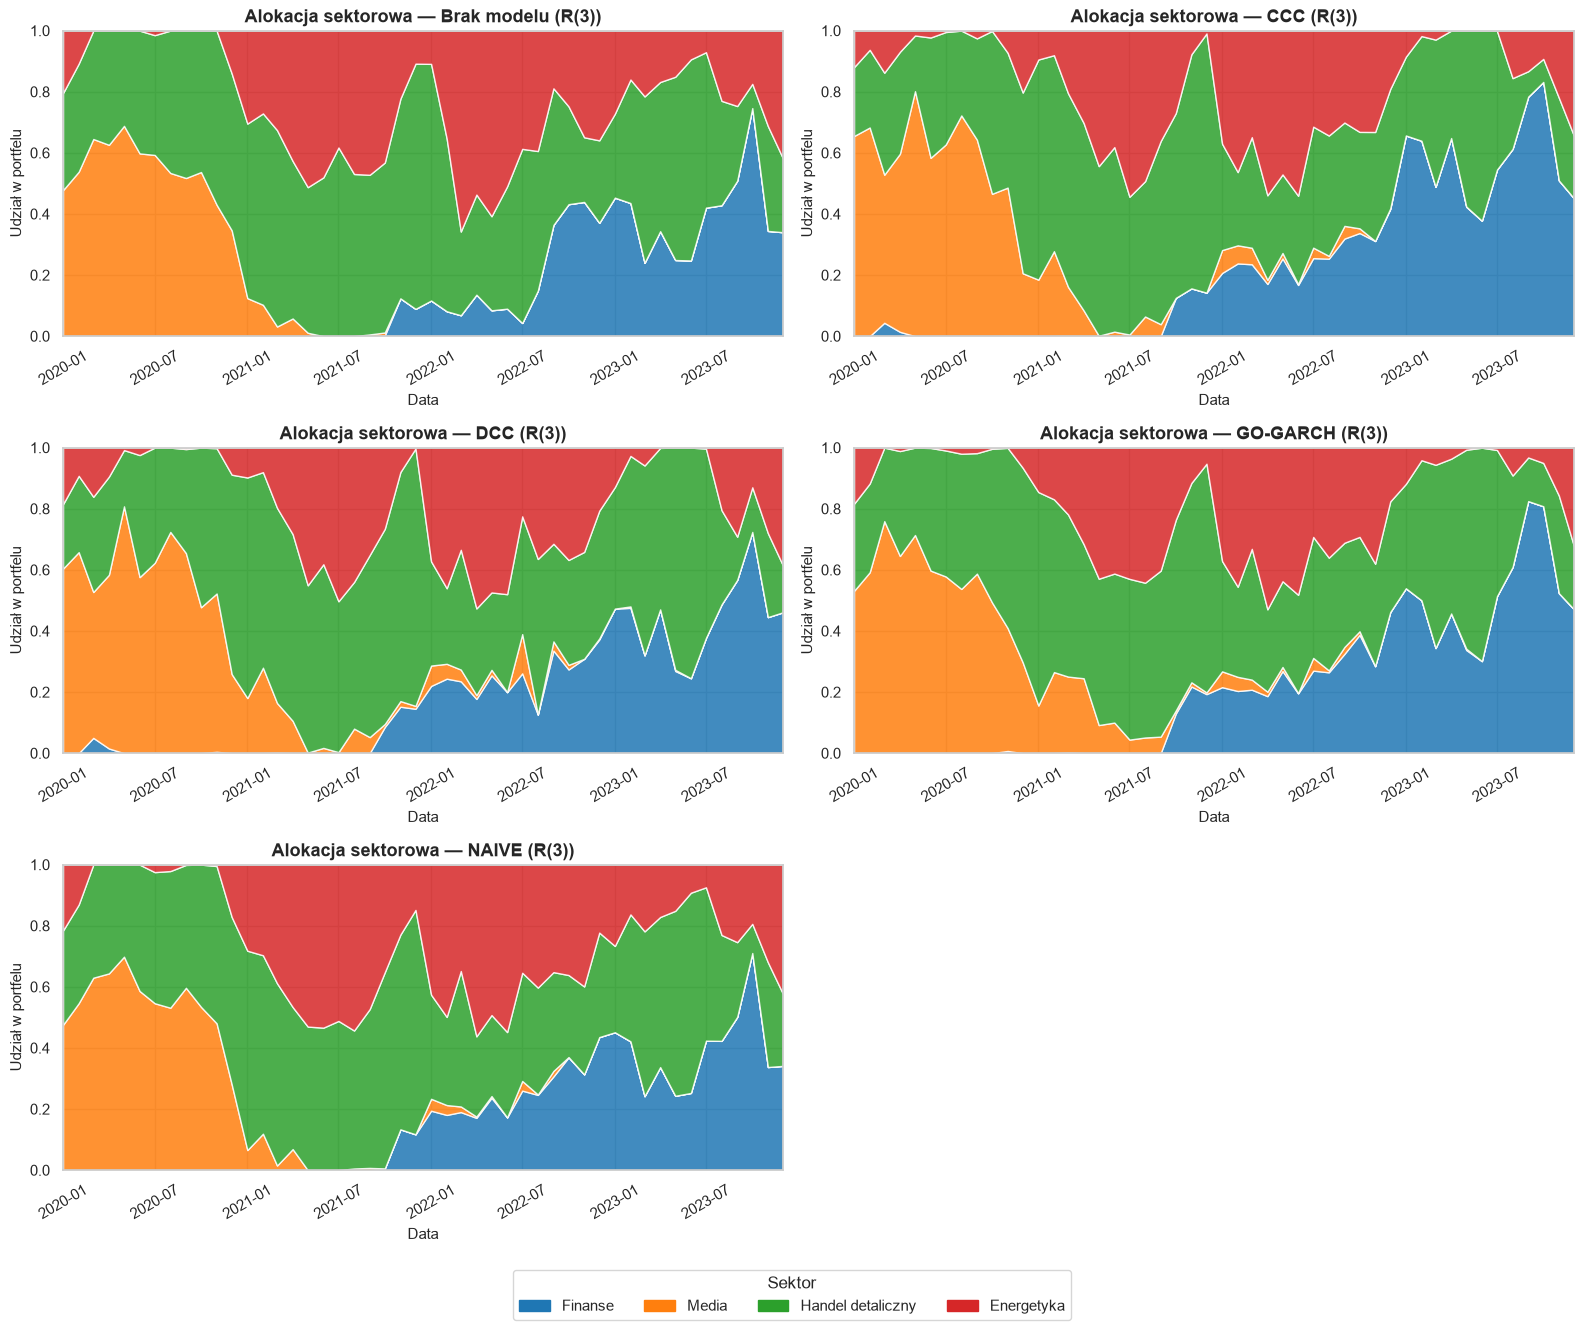

In [17]:
# Filter out benchmark models and identify allocation columns
alloc_df = final_df[~final_df["model"].isin(["Stopa wolna od ryzyka", "WIG20"])].copy()
alloc_df["year_month"] = alloc_df["date"].dt.to_period("M").dt.to_timestamp()

alloc_cols = list(dict.fromkeys(SEGMENT_MAPPING.values()))

# Aggregate daily allocations into monthly averages for each metric and model
monthly_alloc = alloc_df.groupby(["target_metric", "model", "year_month"])[alloc_cols].mean().reset_index()

# Define colors and legend patches for sectors
colors = sns.color_palette("tab10", n_colors=len(alloc_cols))
legend_handles = [mpatches.Patch(color=colors[i], label=alloc_cols[i]) for i in range(len(alloc_cols))]

# Iterate through each target metric to create stacked area grids
unique_metrics = sorted(monthly_alloc["target_metric"].unique())

for metric in unique_metrics:
    metric_data = monthly_alloc[monthly_alloc["target_metric"] == metric]
    unique_models = sorted(metric_data["model"].unique())

    total_plots = len(unique_models)
    ncols = 2
    nrows = math.ceil(total_plots / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4.5 * nrows), squeeze=False)
    axes = axes.flatten()

    # Create stacked area plot for each model
    for idx, model_name in enumerate(unique_models):
        model_data = metric_data[metric_data["model"] == model_name].sort_values("year_month")

        x = model_data["year_month"]
        y_stack = [model_data[col] for col in alloc_cols]

        axes[idx].stackplot(x, y_stack, labels=alloc_cols, colors=colors, alpha=0.85)

        axes[idx].set_title(
            f"Alokacja sektorowa — {model_name} ({metric})",
            fontsize=13,
            fontweight="bold",
        )
        axes[idx].set_xlabel("Data", fontsize=11)
        axes[idx].set_ylabel("Udział w portfelu", fontsize=11)
        axes[idx].set_ylim(0, 1)
        axes[idx].set_xlim(x.min(), x.max())
        axes[idx].tick_params(axis="x", rotation=30)

    # Delete unused subplot axes in the current grid
    for j in range(total_plots, len(axes)):
        fig.delaxes(axes[j])

    # Add single shared figure legend at the bottom for sectors
    fig.legend(
        handles=legend_handles,
        labels=alloc_cols,
        title="Sektor",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=min(len(alloc_cols), 5),
        fontsize=11,
        title_fontsize=12,
        frameon=True,
    )

    # Adjust layout spacing to accommodate the legend
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()